In [1]:
!pip install --upgrade scikit-learn

     |████████████████████████████████| 24.8 MB 22.3 MB/s            
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.23.2
    Uninstalling scikit-learn-0.23.2:
      Successfully uninstalled scikit-learn-0.23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.5.0 which is incompatible.
hypertools 0.7.0 requires scikit-learn!=0.22,<0.24,>=0.19.1, but you have scikit-learn 1.0.2 which is incompatible.


In [2]:
import sklearn
print(sklearn.__version__)  

1.0.2


<a name="1"></a>
# 1. Import libraries

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


# sklearn
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
db = pd.read_csv('/kaggle/input/studentssafe/StudentSafeV2.csv')
print(db.columns)

Index(['Timestamp',
       'Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.',
       'Mobile number (optional)', 'What is your age?', 'What is your gender?',
       'What is your religious identity?',
       'How often you perform your religious activities?',
       'Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside) ',
       'What is your marital status?',
       'Do you have any source of income? (Do you earn money from any source?)',
       'What is your education level?',
       'What is your Institutions? \nPlease select Others if the institution is not in the list and specify manually.',
       'If you have selected Others, then specify your institution's name.',
       'What is your current CGPA up to previous semester or year out of 4.00? Please write in numeric form, for example 3.45.\nMedical Students write pass or fail  instead of 

In [5]:
db

,Timestamp,Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.,Mobile number (optional),What is your age?,What is your gender?,What is your religious identity?,How often you perform your religious activities?,Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside),What is your marital status?,Do you have any source of income? (Do you earn money from any source?),...,What is your father's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above,What is your father's occupation?,What is your mother's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above),What is your mother's occupation?,"How often do you use psychoactive substances? (Substances that affect your mind or mental processes, such as drugs, alcohol, etc.)",How often do you smoke cigarettes?,"How often do you experience anxiety? (Feeling nervous, worried, or uneasy about what might happen)",How often do you experience insomnia (a common sleep disorder that can make it hard to fall asleep or stay asleep )?,"How often do you use electronic devices (laptop, desktop, smartphones, etc.)?",Have you ever thought about taking your own life or Have you ever wanted to end your life?
0,5/19/2025 13:58,Yes,NaN,NaN,Male,Muslim,NaN,Urban,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/20/2025 9:36,Yes,NaN,27.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,5/21/2025 22:33,Yes,1767275257,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,5/21/2025 22:37,Yes,1609098450,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,5/21/2025 22:51,Yes,1737408519,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,8/24/2025 9:08,Yes,NaN,29.0,Male,Muslim,Rarely,Urban,Unmarried,No,...,Secondary,Service Holder,Secondary,Service Holder,Often,Never,Often,Never,Often,Thought but no plan
4000,8/24/2025 9:09,Yes,NaN,27.0,Famale,Non-Muslim,Rarely,Urban,Married,No,...,Secondary,Businessman,Higher education,Service Holder,Often,Often,Often,Never,Often,Never
4001,8/24/2025 9:10,Yes,NaN,29.0,Male,Non-Muslim,Often,Rural,Married,Yes,...,Secondary,Service Holder,Primary,Service Holder,Often,Often,Often,Often,Often,Planned but not attempted
4002,8/24/2025 9:10,Yes,NaN,28.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Homemaker,Regular,Often,Never,Often,Regular,Never


In [6]:
db.shape

(4004, 35)

In [7]:
db = db.drop_duplicates()
db

,Timestamp,Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.,Mobile number (optional),What is your age?,What is your gender?,What is your religious identity?,How often you perform your religious activities?,Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside),What is your marital status?,Do you have any source of income? (Do you earn money from any source?),...,What is your father's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above,What is your father's occupation?,What is your mother's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above),What is your mother's occupation?,"How often do you use psychoactive substances? (Substances that affect your mind or mental processes, such as drugs, alcohol, etc.)",How often do you smoke cigarettes?,"How often do you experience anxiety? (Feeling nervous, worried, or uneasy about what might happen)",How often do you experience insomnia (a common sleep disorder that can make it hard to fall asleep or stay asleep )?,"How often do you use electronic devices (laptop, desktop, smartphones, etc.)?",Have you ever thought about taking your own life or Have you ever wanted to end your life?
0,5/19/2025 13:58,Yes,NaN,NaN,Male,Muslim,NaN,Urban,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/20/2025 9:36,Yes,NaN,27.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,5/21/2025 22:33,Yes,1767275257,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,5/21/2025 22:37,Yes,1609098450,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,5/21/2025 22:51,Yes,1737408519,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,8/24/2025 9:08,Yes,NaN,29.0,Male,Muslim,Rarely,Urban,Unmarried,No,...,Secondary,Service Holder,Secondary,Service Holder,Often,Never,Often,Never,Often,Thought but no plan
4000,8/24/2025 9:09,Yes,NaN,27.0,Famale,Non-Muslim,Rarely,Urban,Married,No,...,Secondary,Businessman,Higher education,Service Holder,Often,Often,Often,Never,Often,Never
4001,8/24/2025 9:10,Yes,NaN,29.0,Male,Non-Muslim,Often,Rural,Married,Yes,...,Secondary,Service Holder,Primary,Service Holder,Often,Often,Often,Often,Often,Planned but not attempted
4002,8/24/2025 9:10,Yes,NaN,28.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Homemaker,Regular,Often,Never,Often,Regular,Never


In [8]:
db.shape

(4003, 35)

In [9]:
#making the column questions to short name columns
new_columns = [
    'timestamp', 'consent', 'mobile_no', 'age', 'gender', 'religion',
    'religious_activity', 'residence', 'marital_status', 'has_income',
    'education_level', 'institution', 'institution_other', 'cgpa',
    'institution_type', 'field_of_study', 'year_of_study', 'class_participation',
    'uni_satisfaction', 'academic_gap', 'session_jam', 'ragging',
    'career_depression', 'family_type', 'family_environment', 'father_education',
    'father_occupation', 'mother_education', 'mother_occupation', 'substance_use',
    'smoking', 'anxiety', 'insomnia', 'device_usage', 'suicidal_risk'
]

db.columns = new_columns

In [10]:
db.columns

Index(['timestamp', 'consent', 'mobile_no', 'age', 'gender', 'religion',
       'religious_activity', 'residence', 'marital_status', 'has_income',
       'education_level', 'institution', 'institution_other', 'cgpa',
       'institution_type', 'field_of_study', 'year_of_study',
       'class_participation', 'uni_satisfaction', 'academic_gap',
       'session_jam', 'ragging', 'career_depression', 'family_type',
       'family_environment', 'father_education', 'father_occupation',
       'mother_education', 'mother_occupation', 'substance_use', 'smoking',
       'anxiety', 'insomnia', 'device_usage', 'suicidal_risk'],
      dtype='object')

In [11]:
db.head()

,timestamp,consent,mobile_no,age,gender,religion,religious_activity,residence,marital_status,has_income,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk
0,5/19/2025 13:58,Yes,NaN,NaN,Male,Muslim,NaN,Urban,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/20/2025 9:36,Yes,NaN,27.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,5/21/2025 22:33,Yes,1767275257,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,5/21/2025 22:37,Yes,1609098450,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,5/21/2025 22:51,Yes,1737408519,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never


In [12]:
db.shape

(4003, 35)

Total number of unique institutions: 101

Total institutions represented: 101
Total students: 4002

Top 10 Institutions:
National University                                         456
Dhaka College                                               406
University of Barishal                                      263
Comilla University                                          261
Islamic University, Bangladesh                              229
Bangladesh Open University                                  220
Jagannath University                                        207
Dhaka International University                              165
Jahangirnagar University                                    143
Chittagong University of Engineering & Technology (CUET)    142
Name: institution, dtype: int64


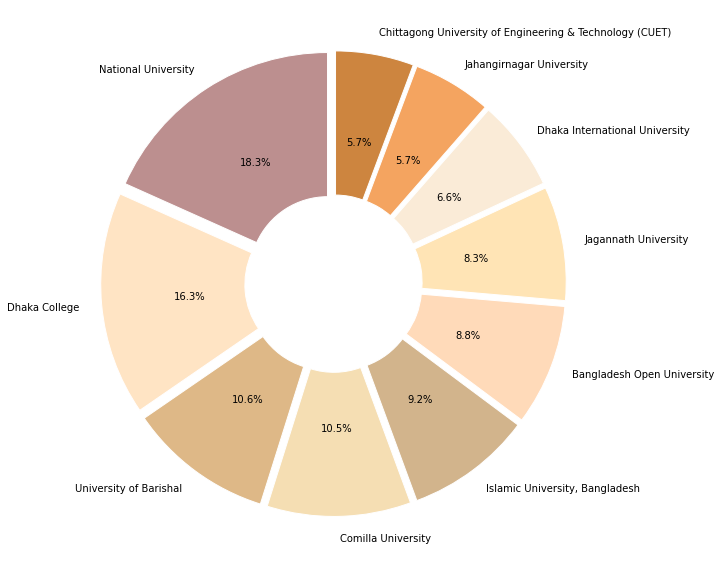

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Count number of unique institutions
unique_institutions = db['institution'].nunique()
print(f"Total number of unique institutions: {unique_institutions}")

# Get value counts for all institutions
institution_counts = db['institution'].value_counts()
print(f"\nTotal institutions represented: {len(institution_counts)}")
print(f"Total students: {institution_counts.sum()}")

# Display top 10 institutions
print("\nTop 10 Institutions:")
print(institution_counts.head(10))

# Create donut chart for top 10 institutions
fig, ax = plt.subplots(figsize=(12, 8))

top_10_institutions = institution_counts.head(10)

# Color palette (you can customize these)
colors = ['#BC8F8F', '#FFE4C4', '#DEB887', '#F5DEB3', '#D2B48C', 
          '#FFDAB9', '#FFE4B5', '#FAEBD7', '#F4A460', '#CD853F']

explode = tuple([0.05] * 10)  # slight separation for all segments

ax.pie(top_10_institutions, labels=top_10_institutions.index, autopct='%1.1f%%',
       colors=colors, startangle=90, explode=explode, 
       wedgeprops=dict(width=0.65, edgecolor='white'))

# ax.set_title('Top 10 Institutions by Student Count', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [14]:
#dropping unnecessary columns
db = db.drop(columns=['timestamp', 'consent', 'mobile_no', 'institution', 'institution_other'])

In [15]:
db.head()

,age,gender,religion,religious_activity,residence,marital_status,has_income,education_level,cgpa,institution_type,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk
0,NaN,Male,Muslim,NaN,Urban,Married,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27.0,Male,Muslim,Regularly,Urban,Married,Yes,Masters',3.55,Govt/Public,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,Bachelors',3.9,Private,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,Bachelors',3.71,Private,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,Bachelors',312,Private,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never


In [16]:
db.shape

(4003, 30)

<a name="2"></a>
# 2. Dataset Preprocessing

In [17]:
db.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4003 entries, 0 to 4003
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4002 non-null   float64
 1   gender               4003 non-null   object 
 2   religion             4003 non-null   object 
 3   religious_activity   4002 non-null   object 
 4   residence            4003 non-null   object 
 5   marital_status       4003 non-null   object 
 6   has_income           4002 non-null   object 
 7   education_level      4002 non-null   object 
 8   cgpa                 4002 non-null   object 
 9   institution_type     4002 non-null   object 
 10  field_of_study       4002 non-null   object 
 11  year_of_study        4002 non-null   object 
 12  class_participation  4002 non-null   object 
 13  uni_satisfaction     4002 non-null   float64
 14  academic_gap         4002 non-null   object 
 15  session_jam          4002 non-null   o

many columns should have been in numeric, but kept as string object.  
 So, it needs to get updated. 

In [18]:
# Convert to numeric, forcing errors to NaN
db['age'] = pd.to_numeric(db['age'], errors='coerce')
db['cgpa'] = pd.to_numeric(db['cgpa'], errors='coerce')
db['uni_satisfaction'] = pd.to_numeric(db['uni_satisfaction'], errors='coerce')
db.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4003 entries, 0 to 4003
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4002 non-null   float64
 1   gender               4003 non-null   object 
 2   religion             4003 non-null   object 
 3   religious_activity   4002 non-null   object 
 4   residence            4003 non-null   object 
 5   marital_status       4003 non-null   object 
 6   has_income           4002 non-null   object 
 7   education_level      4002 non-null   object 
 8   cgpa                 3999 non-null   float64
 9   institution_type     4002 non-null   object 
 10  field_of_study       4002 non-null   object 
 11  year_of_study        4002 non-null   object 
 12  class_participation  4002 non-null   object 
 13  uni_satisfaction     4002 non-null   float64
 14  academic_gap         4002 non-null   object 
 15  session_jam          4002 non-null   o

In [19]:
db.isnull().values.any()

True

It is containing some missing values such as **NaN**. Let's find it out.

In [20]:
# Count null values
print(db.isnull().sum())

# Check for empty strings
for col in db.columns:
    if db[col].dtype == 'object':
        empty_count = (db[col].str.strip() == '').sum()
        if empty_count > 0:
            print(f"Empty strings found in column: {col} — Count: {empty_count}")


age                    1
gender                 0
religion               0
religious_activity     1
residence              0
marital_status         0
has_income             1
education_level        1
cgpa                   4
institution_type       1
field_of_study         1
year_of_study          1
class_participation    1
uni_satisfaction       1
academic_gap           1
session_jam            1
ragging                1
career_depression      1
family_type            1
family_environment     1
father_education       1
father_occupation      1
mother_education       1
mother_occupation      1
substance_use          1
smoking                1
anxiety                1
insomnia               1
device_usage           1
suicidal_risk          1
dtype: int64


The dataset has NaN values in each columns atleast 1.

In [21]:
db[db.isnull().any(axis=1)]

,age,gender,religion,religious_activity,residence,marital_status,has_income,education_level,cgpa,institution_type,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk
0,NaN,Male,Muslim,NaN,Urban,Married,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,24.0,Famale,Muslim,Regularly,Urban,Married,No,Bachelors',NaN,Private,...,Higher education,Service Holder,Higher education,Service Holder,Never,Never,Often,Often,Regular,Never
159,23.0,Famale,Muslim,Regularly,Urban,Unmarried,No,Bachelors',NaN,Private,...,Higher education,Businessman,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
195,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,Bachelors',NaN,Private,...,Higher education,Others,Primary,Homemaker,Never,Never,Never,Never,Often,Attempted once or more


Some missing items or unwanted format values contained in several columns such as '*avg_work_hour*' and '*no_of_projects*'. Let's fix them using imputer. 

In [22]:
import re

# Step 1: Replace unwanted patterns with NaN
pattern = r'^[#?N/A\s]*$'

for col in db.select_dtypes(include='object').columns:
    db[col] = db[col].replace(regex=pattern, value=pd.NA)

# Step 2: Also catch standard missing value strings
db = db.replace(['N/A', 'NA', 'n/a', 'null', 'NULL', 
                  'none', 'None', '', ' '], pd.NA)

# Step 3: Now drop rows with any NaN
db = db.dropna()

In [23]:
db[db.isnull().any(axis=1)]

,age,gender,religion,religious_activity,residence,marital_status,has_income,education_level,cgpa,institution_type,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk


So, now there is no missing vlaues. Let's see how many entries we have here.

In [24]:
# Verify
print(db.shape)

(3999, 30)


In [25]:
import pandas as pd

rows = []

for col in db.columns:
    if db[col].dtype in ['int64', 'float64']:
        dtype = 'Numeric'
        range_cats = f"{db[col].min()} - {db[col].max()}"
        total = '-'
    else:
        dtype = 'Categorical'
        # This removes the empty/NaN causing the leading comma
        categories = db[col].dropna().unique()
        categories = [str(c) for c in categories if str(c).strip() != '']
        range_cats = ', '.join(sorted(categories))
        total = len(categories)
    
    rows.append({
        'Feature Name': col,
        'Data Type': dtype,
        'Range/Categories': range_cats,
        'Total Categories': total
    })

summary = pd.DataFrame(rows)
summary

,Feature Name,Data Type,Range/Categories,Total Categories
0,age,Numeric,2.0 - 78.0,-
1,gender,Categorical,"Famale, Male",2
2,religion,Categorical,"Muslim, Non-Muslim",2
3,religious_activity,Categorical,"Never, Often, Rarely, Regularly",4
4,residence,Categorical,"Rural, Urban",2
5,marital_status,Categorical,"Married, Unmarried",2
6,has_income,Categorical,"No, Yes",2
7,education_level,Categorical,"Bachelors', Masters'",2
8,cgpa,Numeric,0.0 - 364.0,-
9,institution_type,Categorical,"Govt/Public, National, Others, Private",4


But, we gave university satisfaction **uni_satifaction**** score as options in (1-5) range, so it should be considered as categorical. 

In [26]:
db['uni_satisfaction'] = db['uni_satisfaction'].astype(str)

In [27]:
import pandas as pd

rows = []

for col in db.columns:
    if db[col].dtype in ['int64', 'float64']:
        dtype = 'Numeric'
        range_cats = f"{db[col].min()} - {db[col].max()}"
        total = '-'
    else:
        dtype = 'Categorical'
        # This removes the empty/NaN causing the leading comma
        categories = db[col].dropna().unique()
        categories = [str(c) for c in categories if str(c).strip() != '']
        range_cats = ', '.join(sorted(categories))
        total = len(categories)
    
    rows.append({
        'Feature Name': col,
        'Data Type': dtype,
        'Range/Categories': range_cats,
        'Total Categories': total
    })

summary = pd.DataFrame(rows)
summary

,Feature Name,Data Type,Range/Categories,Total Categories
0,age,Numeric,2.0 - 78.0,-
1,gender,Categorical,"Famale, Male",2
2,religion,Categorical,"Muslim, Non-Muslim",2
3,religious_activity,Categorical,"Never, Often, Rarely, Regularly",4
4,residence,Categorical,"Rural, Urban",2
5,marital_status,Categorical,"Married, Unmarried",2
6,has_income,Categorical,"No, Yes",2
7,education_level,Categorical,"Bachelors', Masters'",2
8,cgpa,Numeric,0.0 - 364.0,-
9,institution_type,Categorical,"Govt/Public, National, Others, Private",4


There is a typo in the dataset!!! We put **Famale** instead of '*Female*'. Let's change it.

In [28]:
db['gender'] = db['gender'].replace('Famale', 'Female')    # fix typo

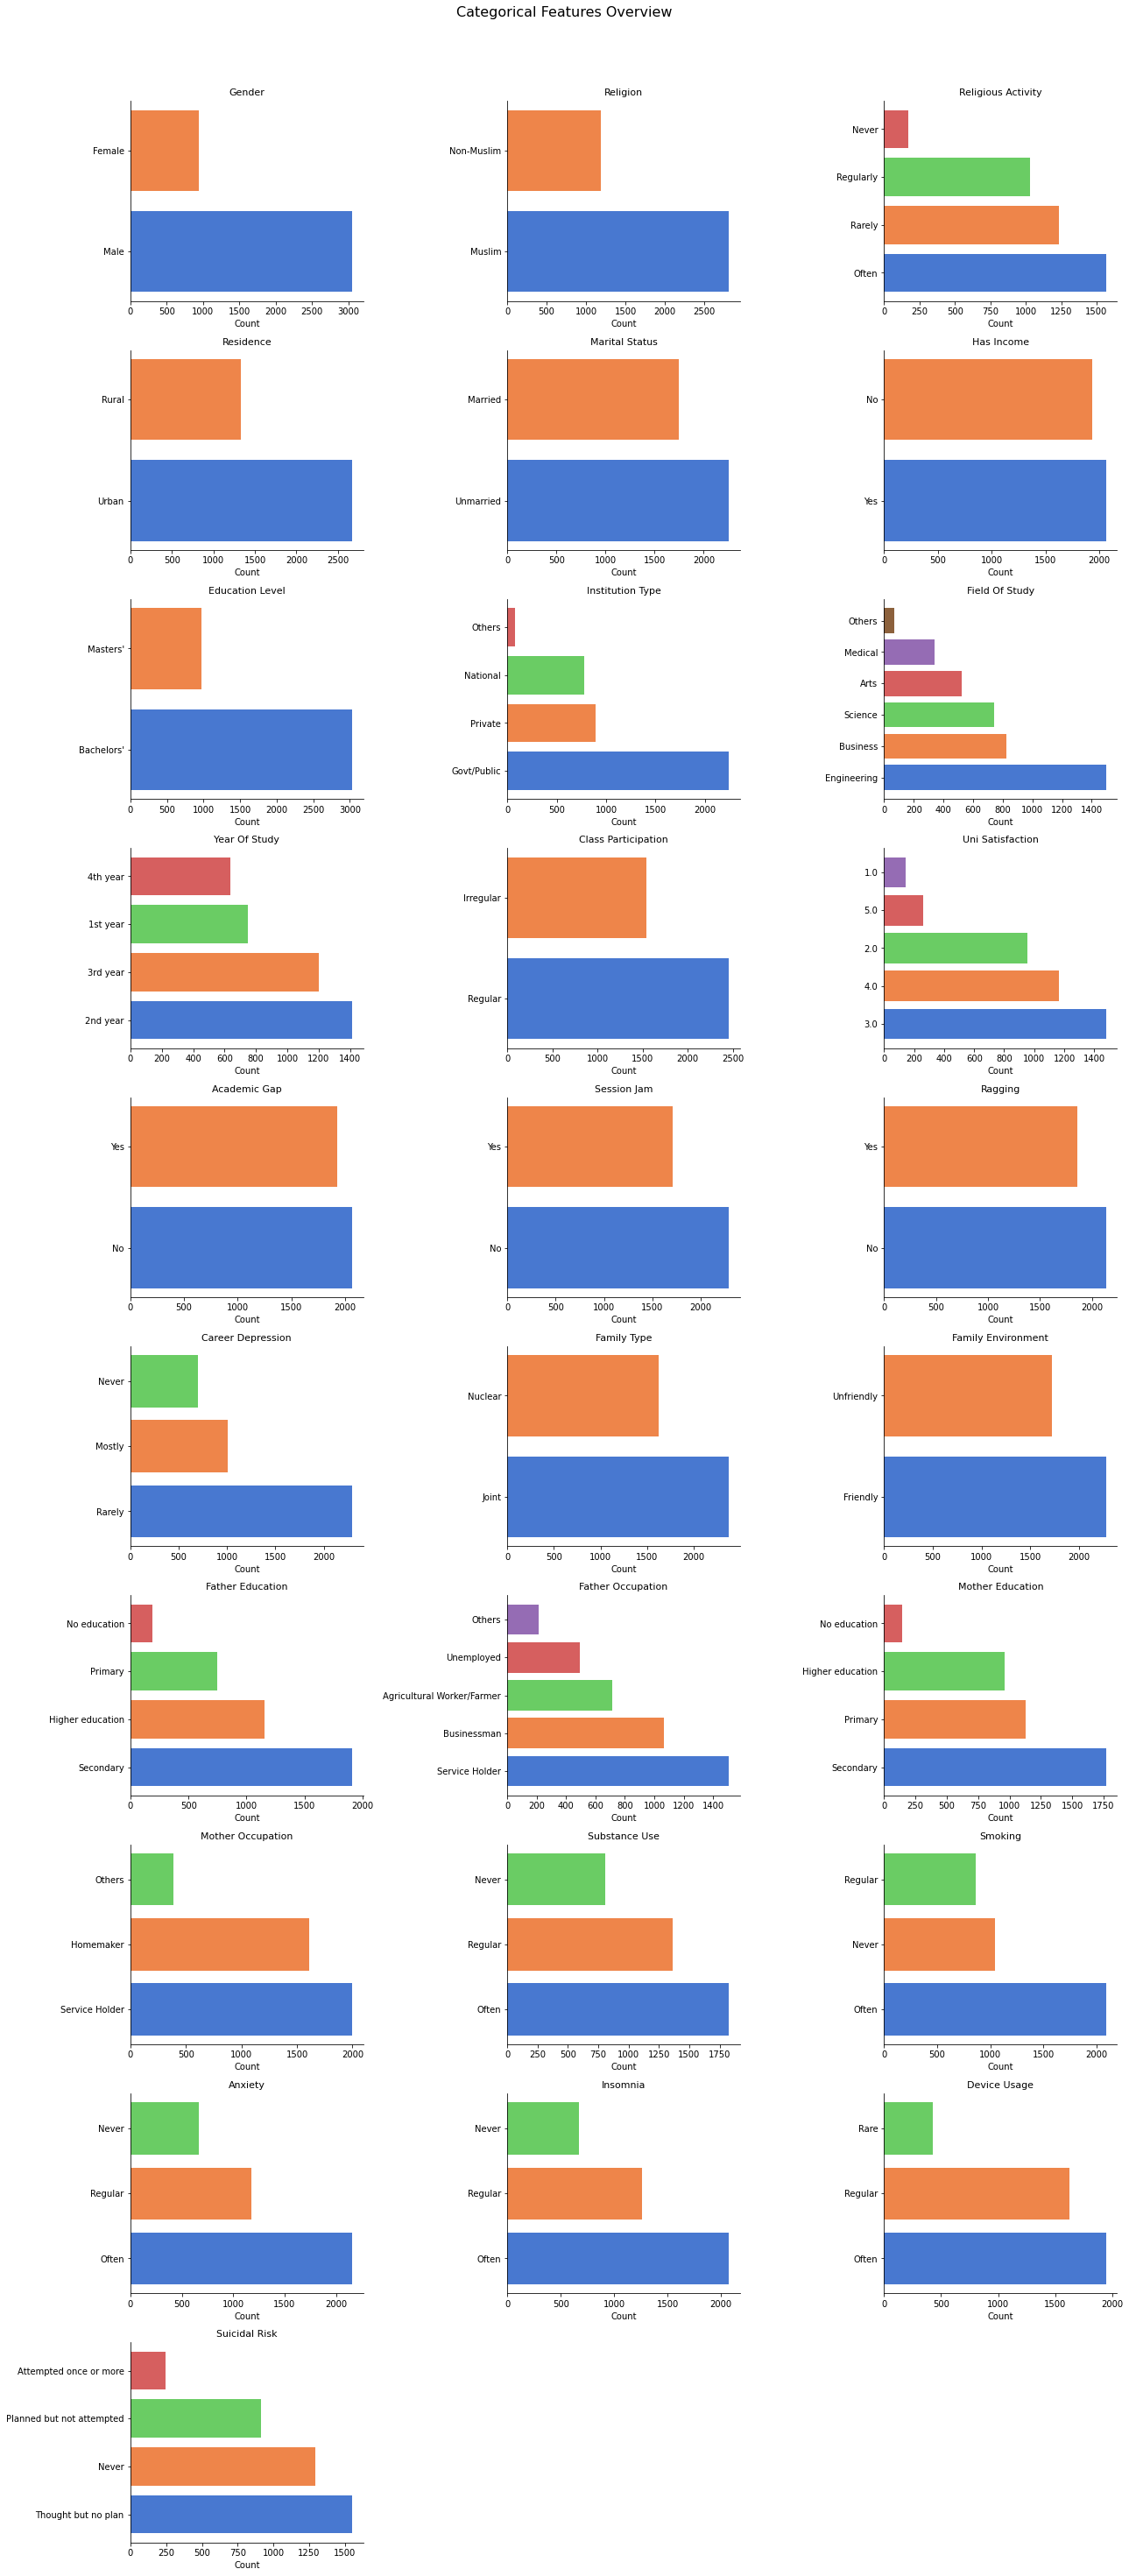

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_cols = db.select_dtypes(include='object').columns.tolist()

# Clean each column
for col in cat_cols:
    db[col] = db[col].replace('', None)

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = db[col].value_counts().dropna()
    axes[i].barh(counts.index, counts.values, 
                 color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Count')
    sns.despine(ax=axes[i])

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features Overview', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('categorical_overview.png', dpi=300, bbox_inches='tight')

#### CGPA entries might contain undesired values. Less than **2.0** and more than **4.0** is not our concern as per Bangladeshi aspect. Then let us drop them. 

In [30]:
# drop the columns having cgpa <2 and >4
db = db[(db['cgpa'] >= 2.0) & (db['cgpa'] <= 4.0)]

In [31]:
db.shape

(3955, 30)

#### Age entries might contain undesired values. As our study is on university students, the typical range is 18-35 years. Then let us drop others. 

In [32]:
# Check before removal
print(f"Total rows: {len(db)}")
print(f"Age range: {db['age'].min()} - {db['age'].max()}")
print(f"Rows outside 18-35: {((db['age'] < 18) | (db['age'] > 35)).sum()}")

# Remove rows outside 18-35 range
db = db[(db['age'] >= 18) & (db['age'] <= 35)]

# Check after removal
print(f"Total rows: {len(db)}")
print(f"Age range: {db['age'].min()} - {db['age'].max()}")
print(f"Rows outside 18-35: {((db['age'] < 18) | (db['age'] > 35)).sum()}")

# Reset index (optional, but recommended)
db = db.reset_index(drop=True)

Total rows: 3955
Age range: 2.0 - 78.0
Rows outside 18-35: 67
Total rows: 3888
Age range: 18.0 - 35.0
Rows outside 18-35: 0


See we came to 3888 from 4003, there were 67 rows got dropped.

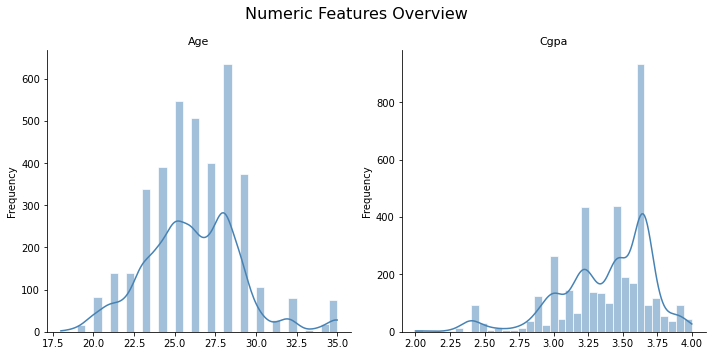

In [33]:
num_cols = db.select_dtypes(include=['int64', 'float64']).columns.tolist()

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.histplot(db[col].dropna(), kde=True, ax=ax,
                color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    sns.despine(ax=ax)

plt.suptitle('Numeric Features Overview', fontsize=16)
plt.tight_layout()
plt.savefig('numeric_overview.png', dpi=300, bbox_inches='tight')

In [34]:
db.columns

Index(['age', 'gender', 'religion', 'religious_activity', 'residence',
       'marital_status', 'has_income', 'education_level', 'cgpa',
       'institution_type', 'field_of_study', 'year_of_study',
       'class_participation', 'uni_satisfaction', 'academic_gap',
       'session_jam', 'ragging', 'career_depression', 'family_type',
       'family_environment', 'father_education', 'father_occupation',
       'mother_education', 'mother_occupation', 'substance_use', 'smoking',
       'anxiety', 'insomnia', 'device_usage', 'suicidal_risk'],
      dtype='object')

# Dataset Invesigations

In [35]:
print("Number of unique types:", db['suicidal_risk'].nunique())
print("Unique types of texts:")
for t in db['suicidal_risk'].unique():
    print("-", t)
print("Text types with their counts:")
for text, count in db['suicidal_risk'].value_counts().items():
    print(f"{text} : {count}")

Number of unique types: 4
Unique types of texts:
- Never
- Attempted once or more
- Planned but not attempted
- Thought but no plan
Text types with their counts:
Thought but no plan : 1506
Never : 1256
Planned but not attempted : 887
Attempted once or more : 239


### Suicidal Risk Categorization

The original `suicidal_risk` responses were mapped into binary categories to enable focused analysis of suicidal risk among undergraduate students. The categorization is as follows:

1. **Risk Negative** – No evidence of suicidal ideation.  
   - Includes participants who responded:  
     - "Never"

2. **Risk Positive** – Presence of suicidal ideation or related behavior.  
   - Includes participants who responded:  
     - "Thought but no plan"  
     - "Planned but not attempted"  
     - "Attempted once or more"

This binary classification simplifies subsequent modeling and statistical analysis by distinguishing between students with and without suicidal risk indicators.

In [36]:
import pandas as pd

# Example mapping
mapping = {
    "Never": "Risk Negative",
    "Thought but no plan": "Risk Positive",
    "Planned but not attempted": "Risk Positive",
    "Attempted once or more": "Risk Positive"
}

# Apply mapping
db['suicidal_risk'] = db['suicidal_risk'].map(mapping)

# Verify the counts
print(db['suicidal_risk'].value_counts())

# Optional: preview unique labels
print(db['suicidal_risk'].unique())


Risk Positive    2632
Risk Negative    1256
Name: suicidal_risk, dtype: int64
['Risk Negative' 'Risk Positive']


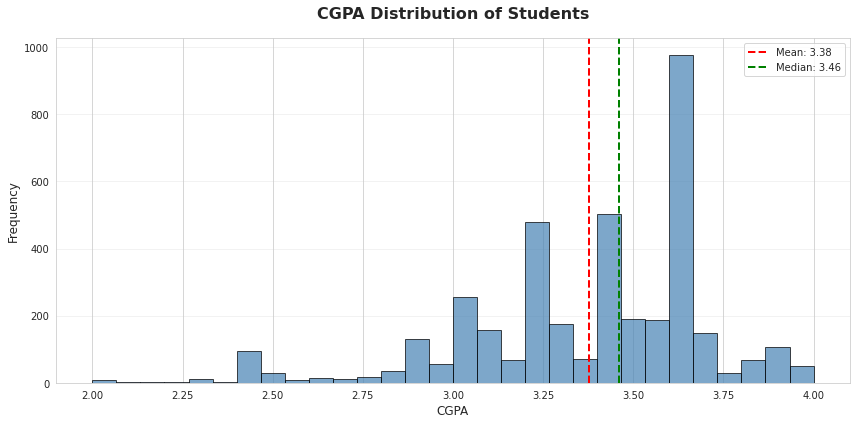

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style for better graphics
sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.figure(figsize=(12, 6))
plt.hist(db['cgpa'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(db['cgpa'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {db["cgpa"].mean():.2f}')
plt.axvline(db['cgpa'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {db["cgpa"].median():.2f}')
plt.title('CGPA Distribution of Students', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

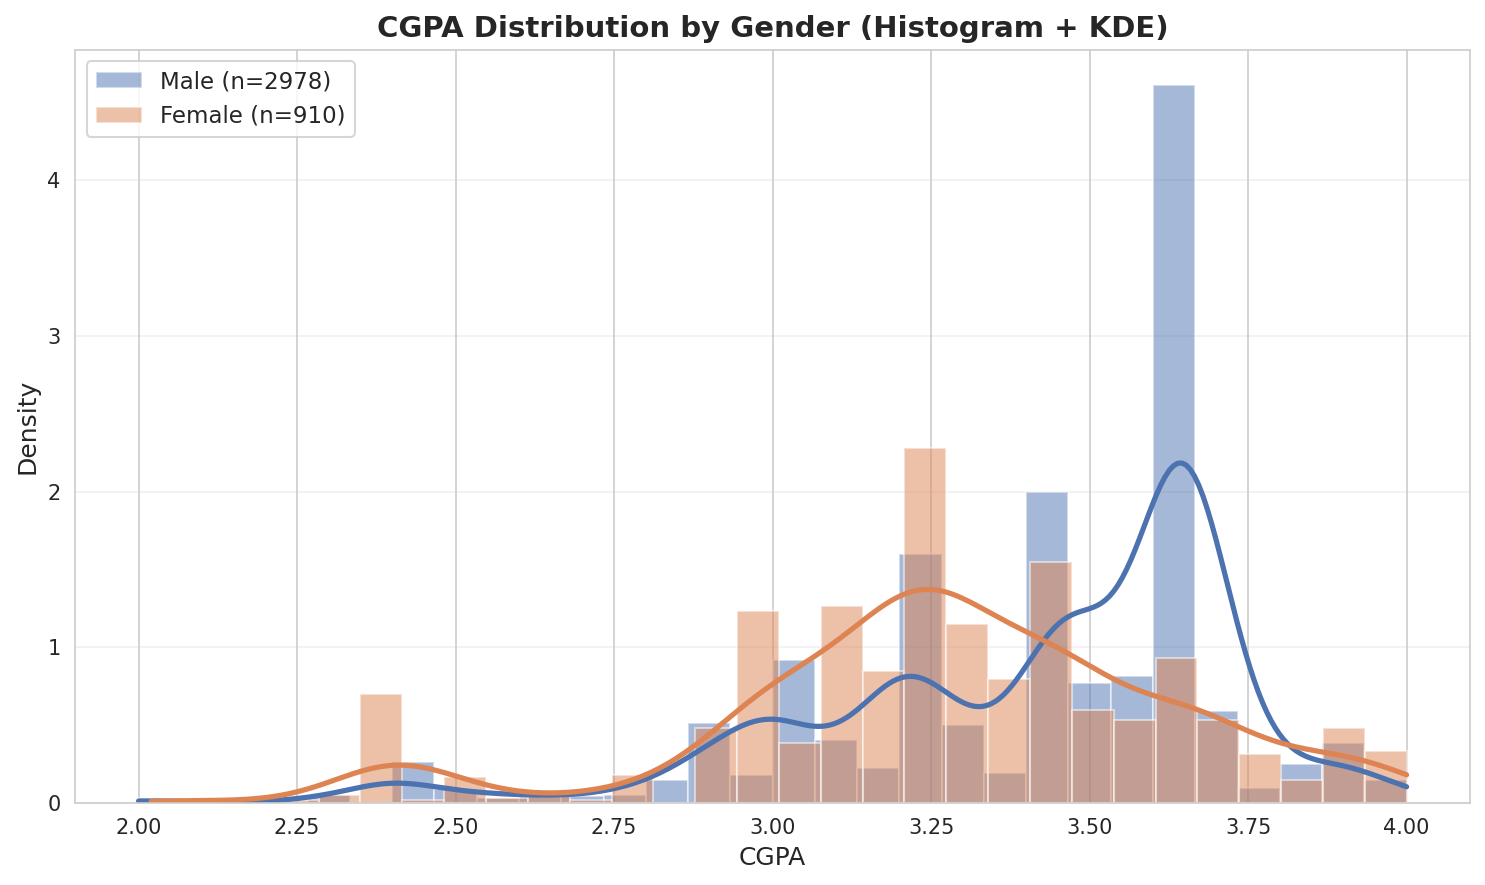

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

colors = {'Male': '#4C72B0', 'Female': '#DD8452'}

for gender, color in colors.items():
    subset = db[db['gender'] == gender]['cgpa'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, color=color, edgecolor='white',
            label=f"{gender} (n={len(subset)})", density=True)
    kde = gaussian_kde(subset)
    x_range = np.linspace(subset.min(), subset.max(), 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5)

ax.set_title('CGPA Distribution by Gender (Histogram + KDE)', fontsize=14, fontweight='bold')
ax.set_xlabel('CGPA', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The CGPA distribution reveals a **notable difference** between male and female students.
Female students show a more **naturally spread distribution**, peaking around **3.25**,
indicating performance is evenly spread across the mid-range (2.75–3.50).
Male students, on the other hand, show a **sharp concentration around 3.65–3.70**,
suggesting a large proportion of male students achieve higher CGPAs.

In summary, **males tend to score higher CGPAs** while **females are more consistent
in the mid-range**, reflecting different academic performance patterns across genders.

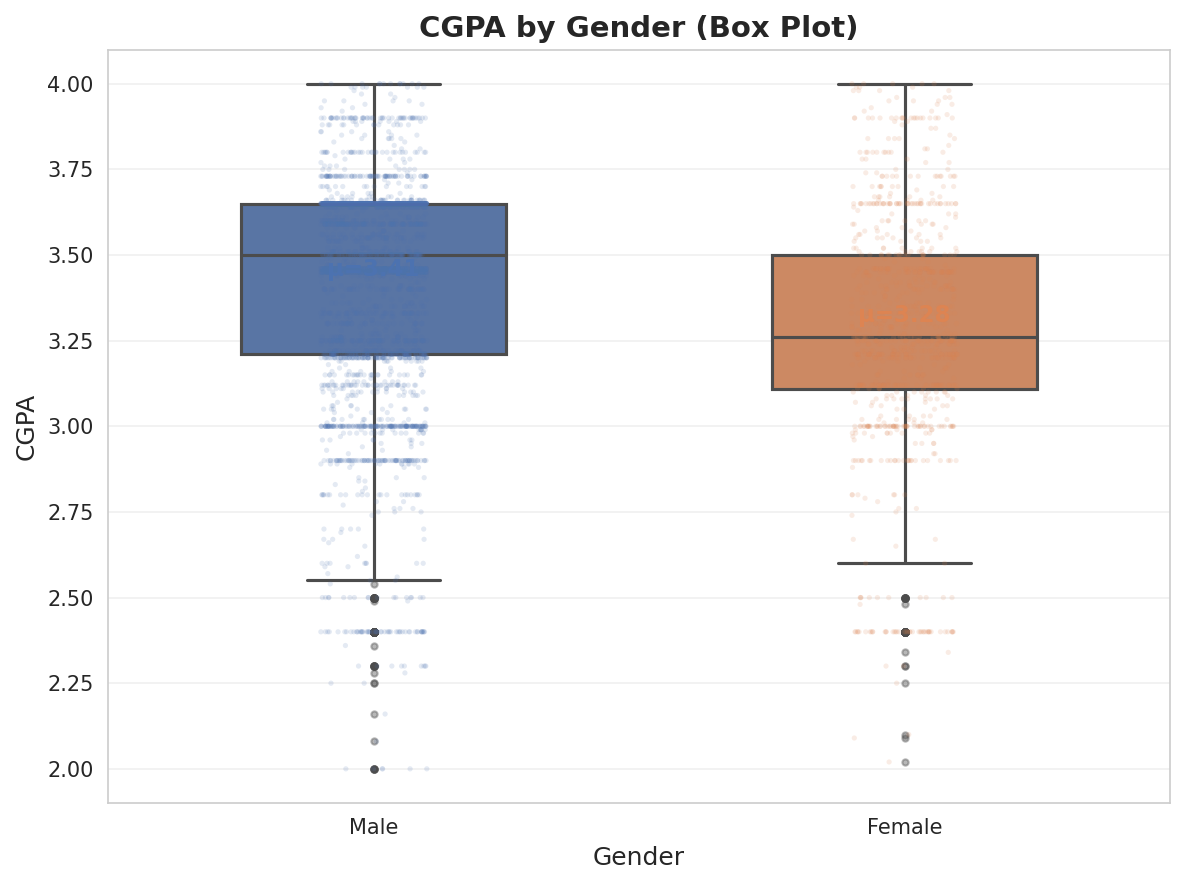

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

colors = {'Male': '#4C72B0', 'Female': '#DD8452'}
gender_order = ['Male', 'Female']

sns.boxplot(data=db, x='gender', y='cgpa', order=gender_order,
            palette=colors, width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)

sns.stripplot(data=db, x='gender', y='cgpa', order=gender_order,
              palette=colors, alpha=0.15, size=2.5, jitter=True, ax=ax)

for i, gender in enumerate(gender_order):
    mean_val = db[db['gender'] == gender]['cgpa'].mean()
    ax.text(i, mean_val + 0.03, f'μ={mean_val:.2f}',
            ha='center', fontsize=11, fontweight='bold',
            color=list(colors.values())[i])

ax.set_title('CGPA by Gender (Box Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('CGPA', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The box plot confirms that **male students have a higher median CGPA (≈3.50)**
compared to **female students (≈3.25)**. The IQR (box range) for males is narrower
(≈3.25–3.65), indicating more consistent performance at the higher end, while females
show a wider spread (≈3.00–3.50), reflecting greater variability in academic performance.

Both groups share a similar minimum (≈2.00) and maximum (4.00), but the overall
distribution shift suggests **male students tend to achieve higher CGPAs on average**
in this dataset.

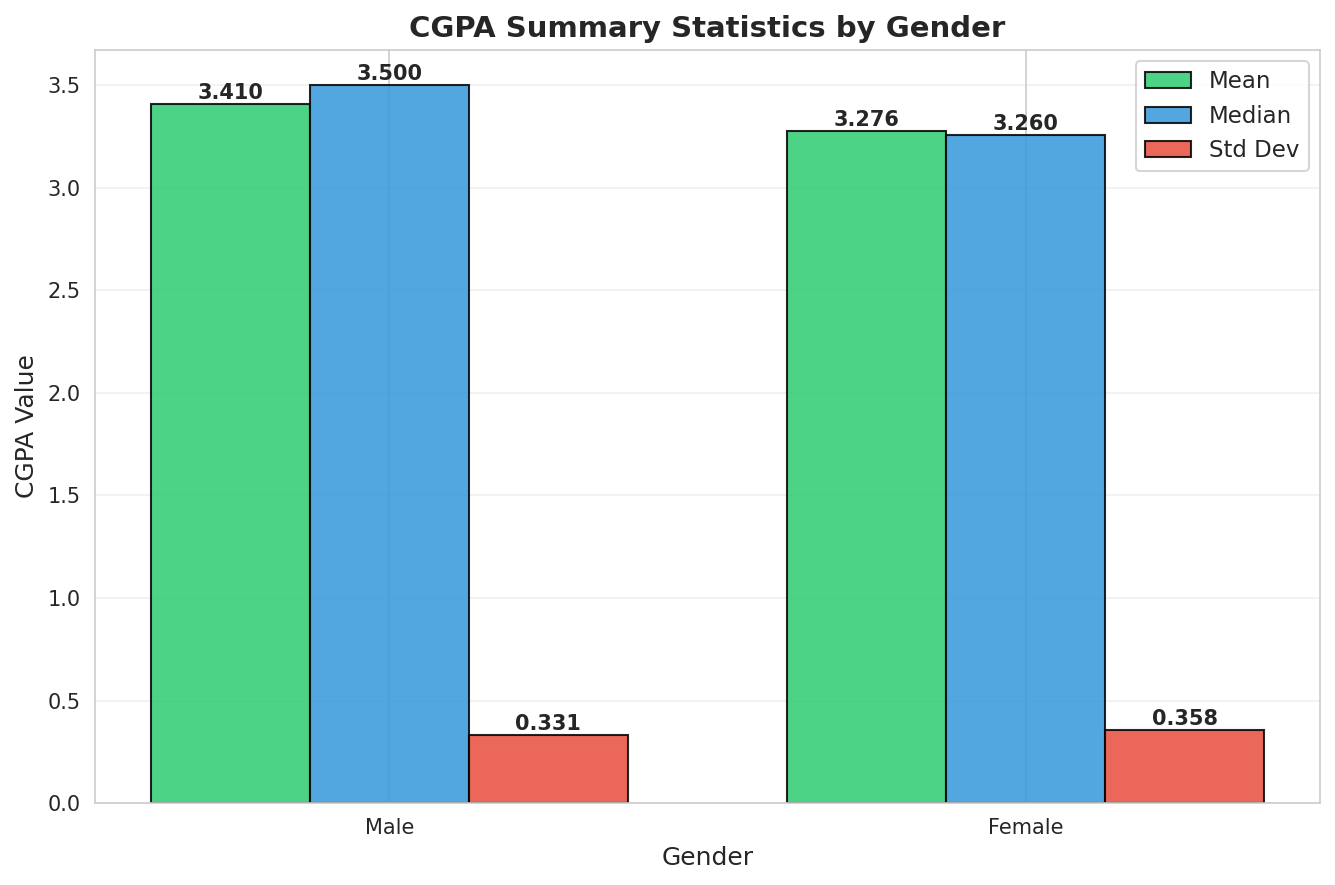

In [40]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

gender_order = ['Male', 'Female']
stats = db.groupby('gender')['cgpa'].agg(['mean', 'median', 'std']).loc[gender_order]

x = np.arange(len(gender_order))
width = 0.25

bars1 = ax.bar(x - width, stats['mean'],   width, label='Mean',    color='#2ecc71', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x,          stats['median'], width, label='Median',  color='#3498db', edgecolor='black', alpha=0.85)
bars3 = ax.bar(x + width,  stats['std'],    width, label='Std Dev', color='#e74c3c', edgecolor='black', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('CGPA Summary Statistics by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('CGPA Value', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(gender_order)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

CGPA is a continuous ratio variable, so **mean**, **std**, **variance**, and scaling are all valid.Since the CGPA distribution is left-skewed (*mean < median*), we should use median over mean as the central measure. The earlier plot confirmed: Male mean=3.38, median=3.46 — *median is more representative*.

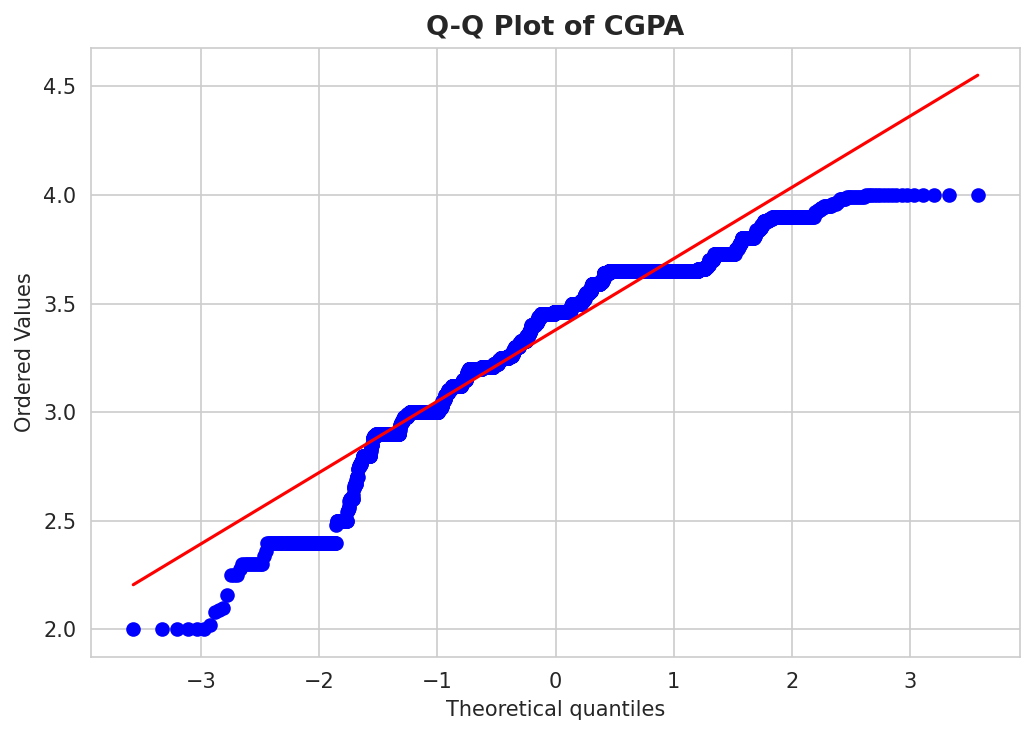

In [41]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
stats.probplot(db['cgpa'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot of CGPA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The staircase pattern is very clear — this confirms CGPA is discrete, not truly continuous. Students have repeated values at fixed intervals (like 3.00, 3.20, 3.45 etc.), which is why the plot has steps instead of a smooth line. The lower tail deviates strongly from the red line, confirming *left skewness and non-normality*.  
Again, Median is meaningful when distribution is skewed. Mean is misleading for skewed distributions. IQR is built on the same philosophy as median — robust to skewness and outliers.

In [42]:
# IQR Method 
Q1 = db['cgpa'].quantile(0.25)
Q3 = db['cgpa'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = db[(db['cgpa'] < lower) | (db['cgpa'] > upper)]

# Z-Score Method (Slide 24)
from scipy import stats
z_scores = stats.zscore(db['cgpa'])
outliers_z = db[abs(z_scores) > 3]

print(f"IQR outliers  : {len(outliers_iqr)}")
print(f"Z-score outliers: {len(outliers_z)}")

IQR outliers  : 152
Z-score outliers: 27


#### Feature Scaling Choice 

Since the CGPA has outliers and is skewed, it is recommended:

| Condition | Recommended Scaler |
|---|---|
| Normal distribution, no outliers | StandardScaler |
| Has outliers, skewed | **RobustScaler** ← this case |
| Neural network / bounded input needed | MinMaxScaler |

#### RobustScaler Implemented

In [43]:
from sklearn.preprocessing import RobustScaler

# Apply Robust Scaling
scaler = RobustScaler()
cgpa_scaled = scaler.fit_transform(db[['cgpa']])

In [44]:
import pandas as pd
from sklearn.preprocessing import RobustScaler


prev_cgpa = pd.DataFrame(db['cgpa'])

# Apply Robust Scaling
scaler = RobustScaler()

db['cgpa'] = scaler.fit_transform(db[['cgpa']])

# ── Show actual value changes ─────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Original CGPA': prev_cgpa['cgpa'],
    'Scaled CGPA'  : db['cgpa'].round(4)
})

# Summary statistics comparison
print("=" * 45)
print(f"{'Statistic':<15} {'Original CGPA':>15} {'Scaled CGPA':>12}")
print("=" * 45)
print(f"{'Mean':<15} {prev_cgpa['cgpa'].mean():>15.4f} {db['cgpa'].mean():>12.4f}")
print(f"{'Median':<15} {prev_cgpa['cgpa'].median():>15.4f} {db['cgpa'].median():>12.4f}")
print(f"{'Std Dev':<15} {prev_cgpa['cgpa'].std():>15.4f} {db['cgpa'].std():>12.4f}")
print(f"{'Min':<15} {prev_cgpa['cgpa'].min():>15.4f} {db['cgpa'].min():>12.4f}")
print(f"{'Max':<15} {prev_cgpa['cgpa'].max():>15.4f} {db['cgpa'].max():>12.4f}")
print(f"{'Q1':<15} {prev_cgpa['cgpa'].quantile(0.25):>15.4f} {db['cgpa'].quantile(0.25):>12.4f}")
print(f"{'Q3':<15} {prev_cgpa['cgpa'].quantile(0.75):>15.4f} {db['cgpa'].quantile(0.75):>12.4f}")
print(f"{'IQR':<15} {(prev_cgpa['cgpa'].quantile(0.75)-prev_cgpa['cgpa'].quantile(0.25)):>15.4f} {(db['cgpa'].quantile(0.75)-db['cgpa'].quantile(0.25)):>12.4f}")
print("=" * 45)

# Show sample of actual row-level changes
print("\n Sample Value Changes (first 10 rows):")
print(comparison.head(10).to_string(index=False))

Statistic         Original CGPA  Scaled CGPA
Mean                     3.3786      -0.1809
Median                   3.4600       0.0000
Std Dev                  0.3421       0.7602
Min                      2.0000      -3.2444
Max                      4.0000       1.2000
Q1                       3.2000      -0.5778
Q3                       3.6500       0.4222
IQR                      0.4500       1.0000

 Sample Value Changes (first 10 rows):
 Original CGPA  Scaled CGPA
          3.55       0.2000
          3.90       0.9778
          3.71       0.5556
          3.40      -0.1333
          2.74      -1.6000
          3.45      -0.0222
          2.98      -1.0667
          3.72       0.5778
          3.12      -0.7556
          3.05      -0.9111


### Now let's go with the **Age** 

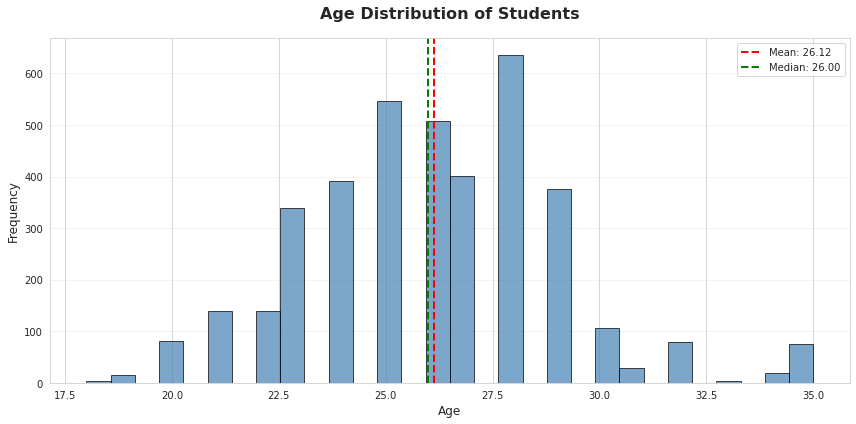

In [45]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
plt.hist(db['age'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(db['age'].mean(),   color='red',   linestyle='--', linewidth=2, label=f'Mean: {db["age"].mean():.2f}')
plt.axvline(db['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {db["age"].median():.2f}')
plt.title('Age Distribution of Students', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

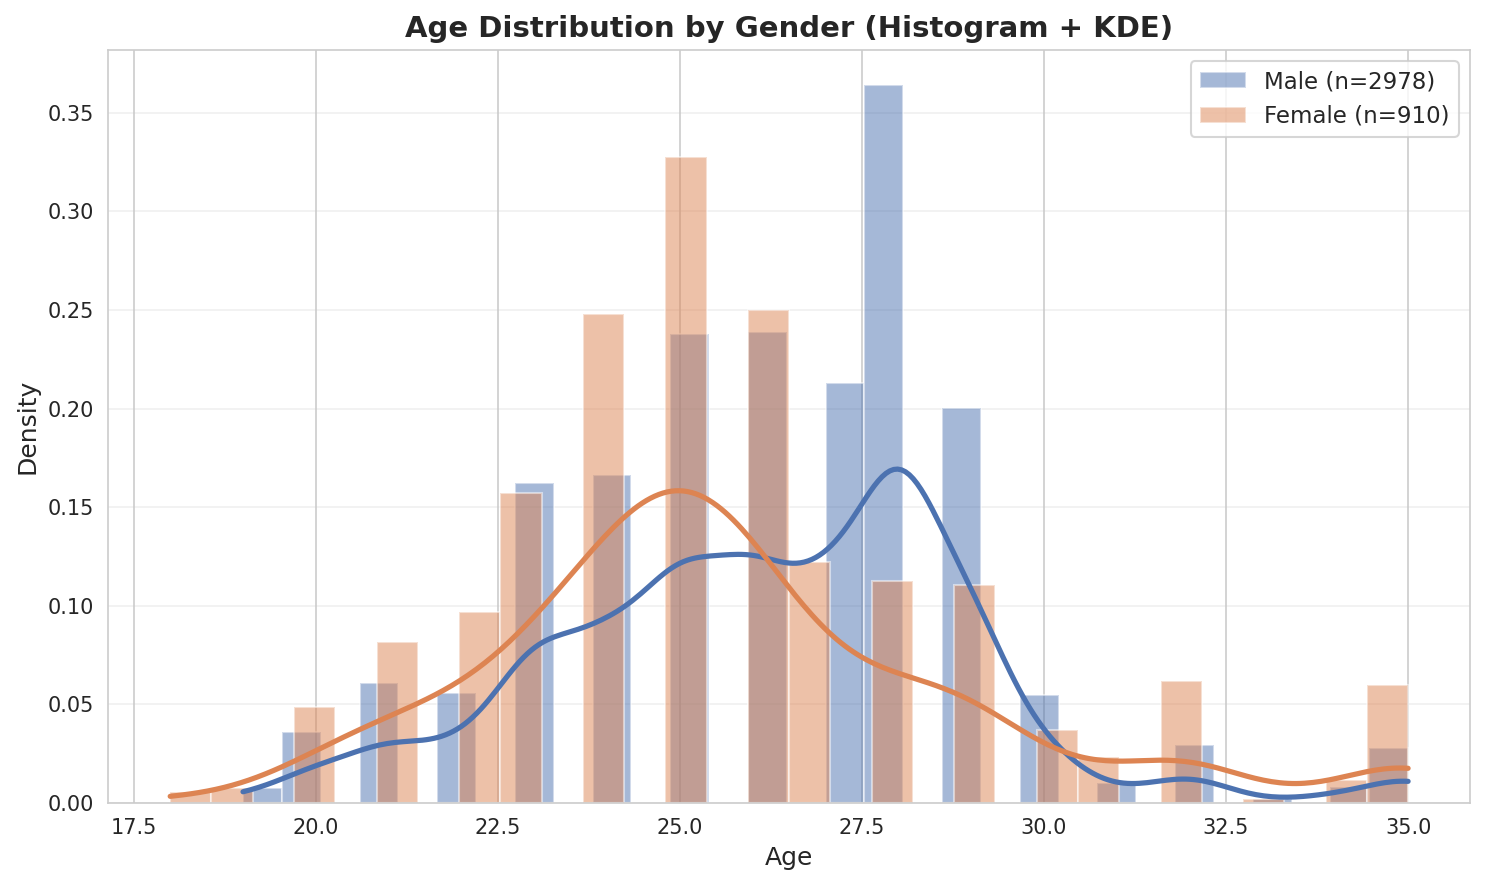

In [46]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
colors = {'Male': '#4C72B0', 'Female': '#DD8452'}

for gender, color in colors.items():
    subset = db[db['gender'] == gender]['age'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, color=color, edgecolor='white',
            label=f"{gender} (n={len(subset)})", density=True)
    kde = gaussian_kde(subset)
    x_range = np.linspace(subset.min(), subset.max(), 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5)

ax.set_title('Age Distribution by Gender (Histogram + KDE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Age Distribution by Gender — Our Observations

1. **Female students are younger** — Kernel Density Estimation (KDE) peaks at ≈25, indicating a tight, concentrated age range.
2. **Male students are older and more spread** — KDE peaks at ≈27–28, reflecting a wider age range across study years.
3. **Both distributions are mildly right-skewed** — small clusters of older students (30–35) exist in both groups.
4. **Unusual female spike at 35+** — a small suspicious cluster similar to the CGPA 3.65 anomaly, worth investigating.

In [47]:
print(db['age'].value_counts().head(10))
print(f"\nStudents aged 35+: {len(db[db['age'] >= 35])}")

28.0    636
25.0    547
26.0    508
27.0    401
24.0    392
29.0    375
23.0    339
22.0    139
21.0    139
30.0    106
Name: age, dtype: int64

Students aged 35+: 75


In [48]:
from scipy.stats import skew, kurtosis
from scipy import stats

print(f"Skewness : {skew(db['age'].dropna()):.3f}")
print(f"Kurtosis : {kurtosis(db['age'].dropna()):.3f}")

# Outlier check
Q1 = db['age'].quantile(0.25)
Q3 = db['age'].quantile(0.75)
IQR = Q3 - Q1
iqr_out = db[(db['age'] < Q1 - 1.5*IQR) | (db['age'] > Q3 + 1.5*IQR)]
z_out = db[abs(stats.zscore(db['age'].dropna())) > 3]

print(f"\nIQR outliers  : {len(iqr_out)}")
print(f"Z-score outliers: {len(z_out)}")

Skewness : 0.329
Kurtosis : 0.620

IQR outliers  : 75
Z-score outliers: 75


For CGPA they were very different (152 vs 27), but for age both methods found exactly 75 outliers. This means age is approximately normal — which is confirmed by the low skewness (0.329) and low kurtosis (0.620). When data is close to normal, IQR and Z-score tend to agree. So, **StandardScaler** is recommended here.

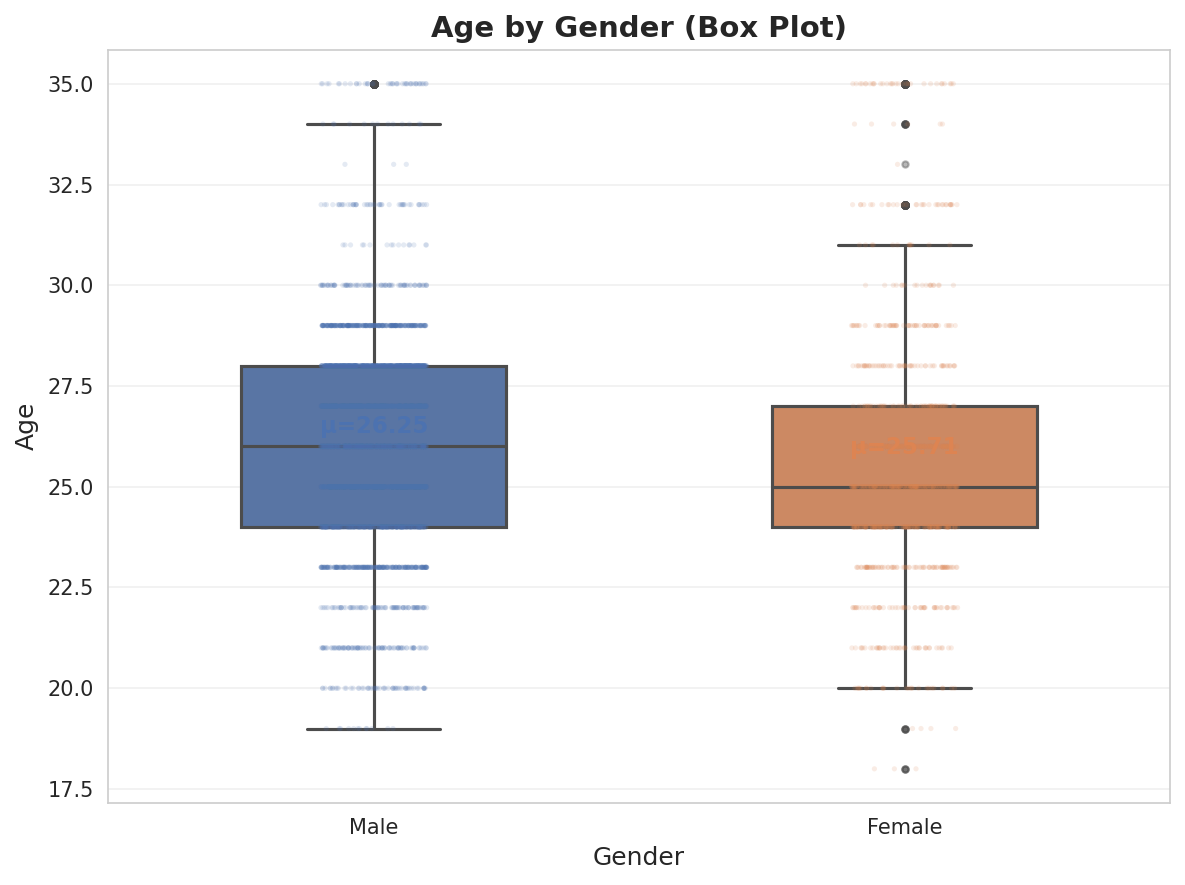

In [49]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
colors = {'Male': '#4C72B0', 'Female': '#DD8452'}
gender_order = ['Male', 'Female']

sns.boxplot(data=db, x='gender', y='age', order=gender_order,
            palette=colors, width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
sns.stripplot(data=db, x='gender', y='age', order=gender_order,
              palette=colors, alpha=0.15, size=2.5, jitter=True, ax=ax)

for i, gender in enumerate(gender_order):
    mean_val = db[db['gender'] == gender]['age'].mean()
    ax.text(i, mean_val + 0.1, f'μ={mean_val:.2f}',
            ha='center', fontsize=11, fontweight='bold',
            color=list(colors.values())[i])

ax.set_title('Age by Gender (Box Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Age', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Age by Gender (Box Plot) — Our Observations

1. **Males have a higher median age (≈26)** compared to females (≈25), consistent with the KDE findings.
2. **Males show a narrower IQR (≈24–28)** indicating more consistent age grouping, while females have a wider spread (≈24–27).
3. **Both groups have outliers above 30+** — visible as scattered dots, confirming the right-skewed tail seen in the KDE plot.
4. **Extreme outliers exist in both groups at 35** — these few data points are worth investigating as potential data entry issues.

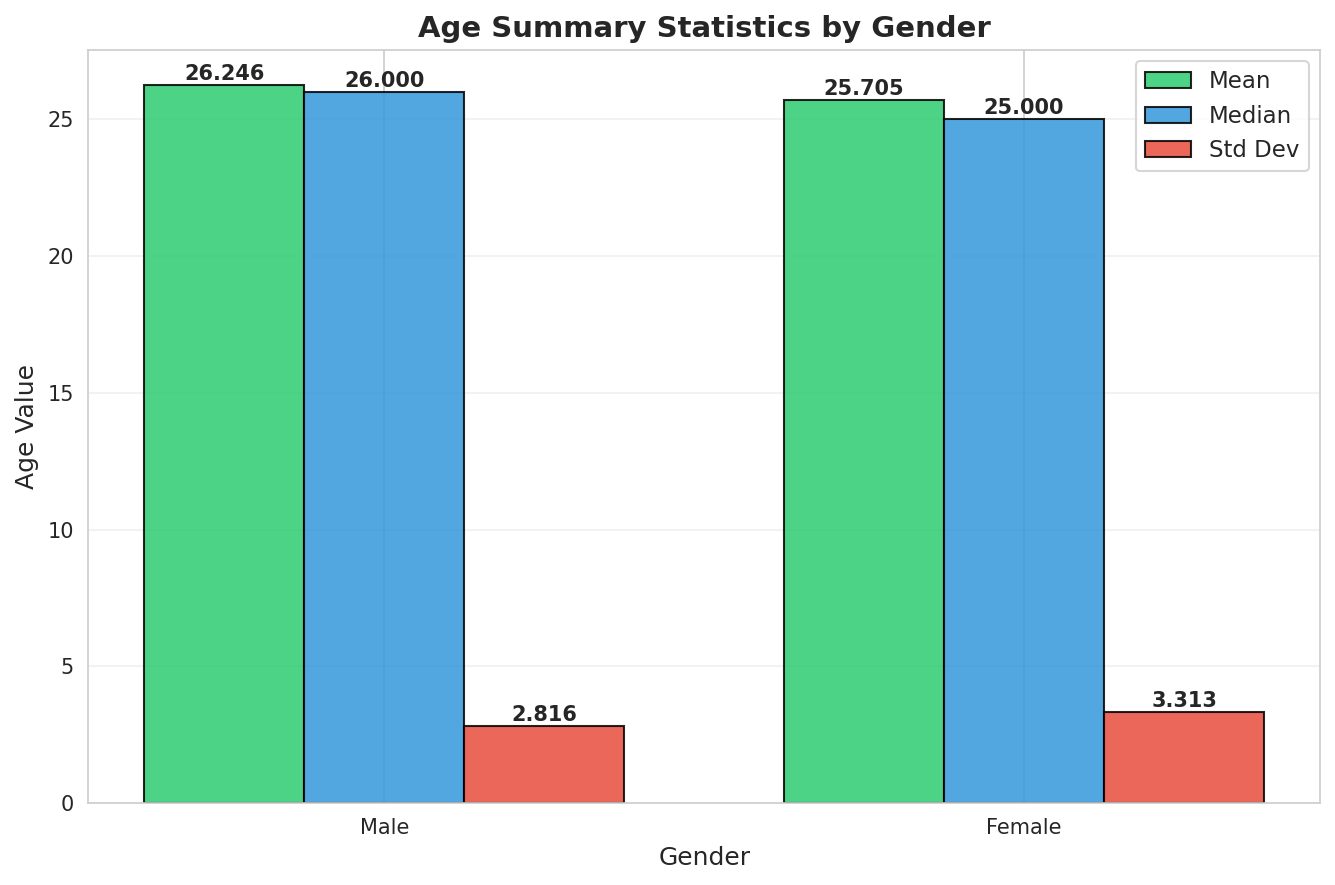

In [50]:
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
gender_order = ['Male', 'Female']
stats = db.groupby('gender')['age'].agg(['mean', 'median', 'std']).loc[gender_order]

x = np.arange(len(gender_order))
width = 0.25

bars1 = ax.bar(x - width, stats['mean'],   width, label='Mean',    color='#2ecc71', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x,          stats['median'], width, label='Median',  color='#3498db', edgecolor='black', alpha=0.85)
bars3 = ax.bar(x + width,  stats['std'],    width, label='Std Dev', color='#e74c3c', edgecolor='black', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.05,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Age Summary Statistics by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Age Value', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(gender_order)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

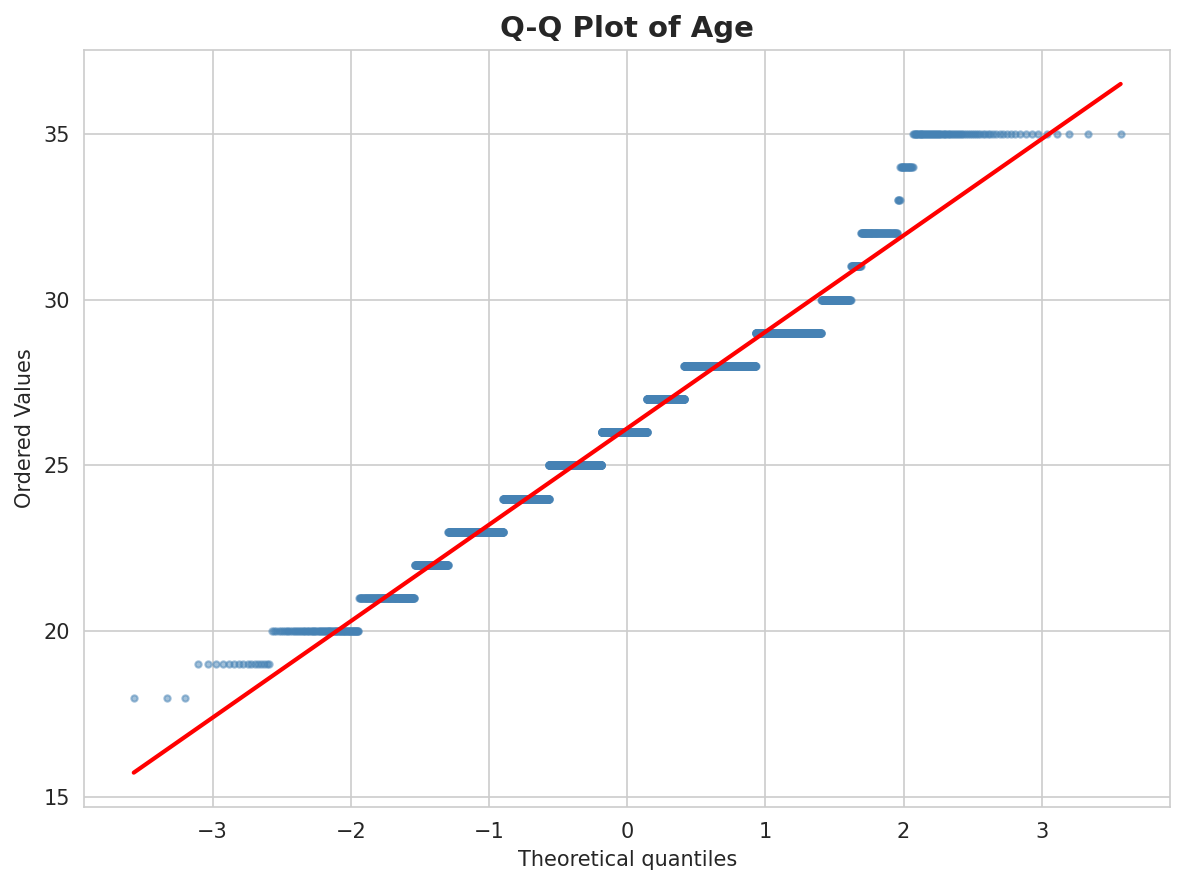

In [51]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
stats.probplot(db['age'].dropna(), dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Age', fontsize=14, fontweight='bold')
ax.get_lines()[0].set(color='steelblue', markersize=3, alpha=0.5)
ax.get_lines()[1].set(color='red', linewidth=2)
plt.tight_layout()
plt.show()

Age follows the red line very well through the entire middle range — only the extreme ends (age 18 and 35) deviate slightly, which matches our outlier findings. So, now let's apply **StandardScalar** on Age.

In [52]:
from sklearn.preprocessing import StandardScaler

prev_age = pd.DataFrame(db['age'])

# Apply Standard Scaling
scaler = StandardScaler()
db['age'] = scaler.fit_transform(db[['age']])

# ── Show actual value changes ─────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Original Age': prev_age['age'],
    'Scaled Age'  : db['age'].round(4)
})

# Summary statistics comparison
print("=" * 45)
print(f"{'Statistic':<15} {'Original Age':>15} {'Scaled Age':>12}")
print("=" * 45)
print(f"{'Mean':<15} {prev_age['age'].mean():>15.4f} {db['age'].mean():>12.4f}")
print(f"{'Median':<15} {prev_age['age'].median():>15.4f} {db['age'].median():>12.4f}")
print(f"{'Std Dev':<15} {prev_age['age'].std():>15.4f} {db['age'].std():>12.4f}")
print(f"{'Min':<15} {prev_age['age'].min():>15.4f} {db['age'].min():>12.4f}")
print(f"{'Max':<15} {prev_age['age'].max():>15.4f} {db['age'].max():>12.4f}")
print(f"{'Q1':<15} {prev_age['age'].quantile(0.25):>15.4f} {db['age'].quantile(0.25):>12.4f}")
print(f"{'Q3':<15} {prev_age['age'].quantile(0.75):>15.4f} {db['age'].quantile(0.75):>12.4f}")
print(f"{'IQR':<15} {(prev_age['age'].quantile(0.75)-prev_age['age'].quantile(0.25)):>15.4f} {(db['age'].quantile(0.75)-db['age'].quantile(0.25)):>12.4f}")
print("=" * 45)

# Show sample of actual row-level changes
print("\n Sample Value Changes (first 10 rows):")
print(comparison.head(10).to_string(index=False))

Statistic          Original Age   Scaled Age
Mean                    26.1193       0.0000
Median                  26.0000      -0.0405
Std Dev                  2.9482       1.0001
Min                     18.0000      -2.7544
Max                     35.0000       3.0127
Q1                      24.0000      -0.7190
Q3                      28.0000       0.6380
IQR                      4.0000       1.3569

 Sample Value Changes (first 10 rows):
 Original Age  Scaled Age
         27.0      0.2988
         27.0      0.2988
         26.0     -0.0405
         22.0     -1.3974
         27.0      0.2988
         23.0     -1.0582
         27.0      0.2988
         26.0     -0.0405
         26.0     -0.0405
         27.0      0.2988


In [53]:
db

,age,gender,religion,religious_activity,residence,marital_status,has_income,education_level,cgpa,institution_type,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk
0,0.298752,Male,Muslim,Regularly,Urban,Married,Yes,Masters',0.200000,Govt/Public,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Risk Negative
1,0.298752,Male,Muslim,Regularly,Urban,Unmarried,Yes,Bachelors',0.977778,Private,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Risk Positive
2,-0.040485,Male,Muslim,Often,Urban,Unmarried,Yes,Bachelors',0.555556,Private,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Risk Negative
3,-1.397434,Male,Muslim,Often,Urban,Unmarried,No,Bachelors',-0.133333,Private,...,Higher education,Others,Higher education,Homemaker,Never,Never,Often,Often,Regular,Risk Negative
4,0.298752,Male,Muslim,Regularly,Rural,Married,Yes,Bachelors',-1.600000,National,...,Higher education,Others,Primary,Homemaker,Never,Never,Never,Often,Regular,Risk Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,0.977227,Male,Muslim,Rarely,Urban,Unmarried,No,Bachelors',0.288889,Govt/Public,...,Secondary,Service Holder,Secondary,Service Holder,Often,Never,Often,Never,Often,Risk Positive
3884,0.298752,Female,Non-Muslim,Rarely,Urban,Married,No,Masters',0.266667,Govt/Public,...,Secondary,Businessman,Higher education,Service Holder,Often,Often,Often,Never,Often,Risk Negative
3885,0.977227,Male,Non-Muslim,Often,Rural,Married,Yes,Bachelors',-0.022222,Govt/Public,...,Secondary,Service Holder,Primary,Service Holder,Often,Often,Often,Often,Often,Risk Positive
3886,0.637989,Male,Muslim,Regularly,Urban,Married,Yes,Bachelors',0.288889,Govt/Public,...,Secondary,Businessman,Secondary,Homemaker,Regular,Often,Never,Often,Regular,Risk Negative


In [54]:
# Check unique values for all categorical columns
cat_cols = ['gender', 'religion', 'religious_activity', 'residence',
            'marital_status', 'has_income', 'education_level',
            'institution_type', 'field_of_study', 'year_of_study',
            'class_participation', 'uni_satisfaction', 'academic_gap',
            'session_jam', 'ragging', 'career_depression', 'family_type',
            'family_environment', 'father_education', 'father_occupation',
            'mother_education', 'mother_occupation', 'substance_use',
            'smoking', 'anxiety', 'insomnia', 'device_usage', 'suicidal_risk']

for col in cat_cols:
    print(f"{col:<25} → {sorted(db[col].unique())}")

gender                    → ['Female', 'Male']
religion                  → ['Muslim', 'Non-Muslim']
religious_activity        → ['Never', 'Often', 'Rarely', 'Regularly']
residence                 → ['Rural', 'Urban']
marital_status            → ['Married', 'Unmarried']
has_income                → ['No', 'Yes']
education_level           → ["Bachelors'", "Masters'"]
institution_type          → ['Govt/Public', 'National', 'Others', 'Private']
field_of_study            → ['Arts', 'Business', 'Engineering', 'Medical', 'Others', 'Science']
year_of_study             → ['1st year', '2nd year', '3rd year', '4th year']
class_participation       → ['Irregular', 'Regular']
uni_satisfaction          → ['1.0', '2.0', '3.0', '4.0', '5.0']
academic_gap              → ['No', 'Yes']
session_jam               → ['No', 'Yes']
ragging                   → ['No', 'Yes']
career_depression         → ['Mostly', 'Never', 'Rarely']
family_type               → ['Joint', 'Nuclear']
family_environment        → ['Fri

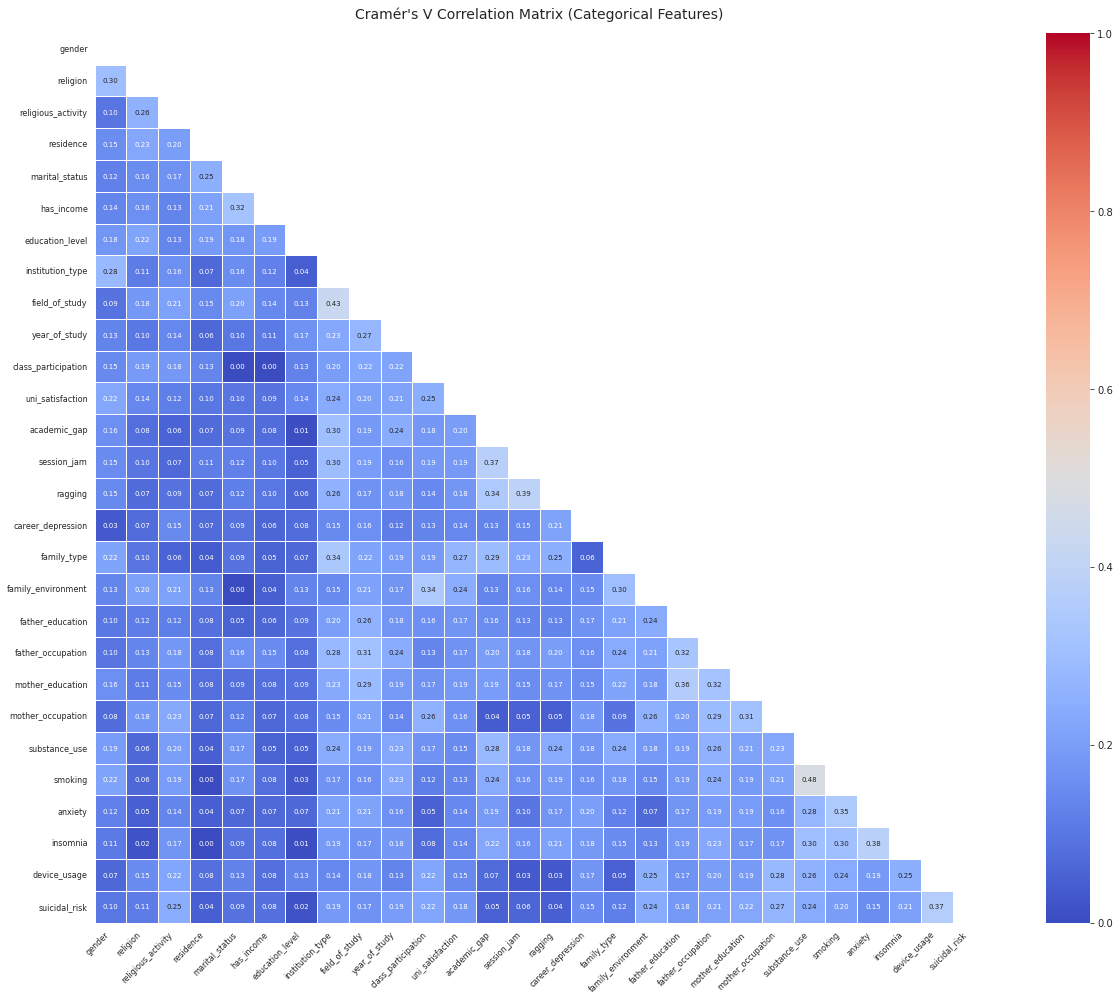

In [55]:
import pandas as pd

import numpy as np

from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt

import seaborn as sns

# Cramér's V function

def cramers_v(x, y):

    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))

    rcorr = r - ((r-1)**2)/(n-1)

    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns only

cat_cols = db.select_dtypes(include='object').columns.tolist()

# Build Cramér's V matrix

cramers_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))), 

                               index=cat_cols, columns=cat_cols)

for col1 in cat_cols:

    for col2 in cat_cols:

        cramers_matrix.loc[col1, col2] = cramers_v(db[col1].dropna(), db[col2].dropna())

# Plot heatmap

plt.figure(figsize=(18, 14))

mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(

    cramers_matrix,

    mask=mask,

    annot=True,

    fmt='.2f',

    cmap='coolwarm',

    vmin=0, vmax=1,

    linewidths=0.5,

    annot_kws={"size": 7},

    square=True

)

plt.title("Cramér's V Correlation Matrix (Categorical Features)", fontsize=14, pad=15)

plt.xticks(rotation=45, ha='right', fontsize=8)

plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

plt.show()

All 28 categorical features exhibit weak to moderate inter-feature association (*Cramér's V < 0.50*), with no evidence of multicollinearity. This confirms that the feature set is **non-redundant** and **suitable** for direct use in classification without further dimensionality reduction.

In [56]:
target_corr = cramers_matrix['suicidal_risk'].drop('suicidal_risk').sort_values(ascending=False)

print(target_corr)

device_usage           0.365769
mother_occupation      0.272305
religious_activity     0.245854
family_environment     0.241271
substance_use          0.237169
mother_education       0.223002
class_participation    0.220875
father_occupation      0.208326
insomnia               0.205203
smoking                0.196188
year_of_study          0.193162
institution_type       0.185632
father_education       0.184448
uni_satisfaction       0.180017
field_of_study         0.171552
anxiety                0.153938
career_depression      0.150536
family_type            0.119505
religion               0.112040
gender                 0.099361
marital_status         0.089712
has_income             0.084935
session_jam            0.060853
academic_gap           0.048229
ragging                0.044786
residence              0.044446
education_level        0.016562
Name: suicidal_risk, dtype: float64


The values suggest that **excessive device use** is a strong behavioral signal for student suicide risk in Bangladesh.

### Feature Classification & Preprocessing Strategy

#### Numerical Features

| Feature | Type | Scaler | Justification |
|---------|------|--------|---------------|
| `age` | Continuous Numeric | StandardScaler | Normally distributed, no extreme outliers |
| `cgpa` | Continuous Numeric | RobustScaler | Slight skew with low outliers, median-based scaling preferred |

---

#### Ordinal Categorical Features
> *Have a natural order — encoded using OrdinalEncoder*

| Feature | Type | Order | Encoding |
|---------|------|-------|----------|
| `religious_activity` | Ordinal | Never → Rarely → Often → Regularly | OrdinalEncoder |
| `uni_satisfaction` | Ordinal | 1.0 → 2.0 → 3.0 → 4.0 → 5.0 | OrdinalEncoder |
| `career_depression` | Ordinal | Never → Rarely → Mostly | OrdinalEncoder |
| `substance_use` | Ordinal | Never → Often → Regular | OrdinalEncoder |
| `smoking` | Ordinal | Never → Often → Regular | OrdinalEncoder |
| `anxiety` | Ordinal | Never → Often → Regular | OrdinalEncoder |
| `insomnia` | Ordinal | Never → Often → Regular | OrdinalEncoder |
| `device_usage` | Ordinal | Rare → Often → Regular | OrdinalEncoder |
| `father_education` | Ordinal | No education → Primary → Secondary → Higher education | OrdinalEncoder |
| `mother_education` | Ordinal | No education → Primary → Secondary → Higher education | OrdinalEncoder |
| `year_of_study` | Ordinal | 1st year → 2nd year → 3rd year → 4th year | OrdinalEncoder |

---

#### Nominal Categorical Features
> *No natural order — encoded using OneHotEncoder for linear models, LabelEncoder for tree models*

| Feature | Type | Unique Values | Encoding (Linear) | Encoding (Tree) |
|---------|------|---------------|-------------------|-----------------|
| `religion` | Nominal | Muslim, Non-Muslim | OneHotEncoder | LabelEncoder |
| `residence` | Nominal | Rural, Urban | OneHotEncoder | LabelEncoder |
| `institution_type` | Nominal | Govt/Public, National, Private, Others | OneHotEncoder | LabelEncoder |
| `field_of_study` | Nominal | Arts, Business, Engineering, Medical, Science, Others | OneHotEncoder | LabelEncoder |
| `family_type` | Nominal | Joint, Nuclear | OneHotEncoder | LabelEncoder |
| `family_environment` | Nominal | Friendly, Unfriendly | OneHotEncoder | LabelEncoder |
| `father_occupation` | Nominal | Agricultural Worker, Businessman, Service Holder, Unemployed, Others | OneHotEncoder | LabelEncoder |
| `mother_occupation` | Nominal | Homemaker, Service Holder, Others | OneHotEncoder | LabelEncoder |

---

#### Binary Features
> *Two-valued — directly mapped to 0/1*

| Feature | Type | Mapping | Encoding |
|---------|------|---------|----------|
| `gender` | Binary | Female = 0, Male = 1 | Binary Map |
| `marital_status` | Binary | Married = 0, Unmarried = 1 | Binary Map |
| `has_income` | Binary | No = 0, Yes = 1 | Binary Map |
| `class_participation` | Binary | Irregular = 0, Regular = 1 | Binary Map |
| `academic_gap` | Binary | No = 0, Yes = 1 | Binary Map |
| `session_jam` | Binary | No = 0, Yes = 1 | Binary Map |
| `ragging` | Binary | No = 0, Yes = 1 | Binary Map |
| `education_level` | Binary | Bachelors = 0, Masters = 1 | Binary Map |

---

#### Target Variable

| Feature | Type | Values | Encoding |
|---------|------|--------|----------|
| `suicidal_risk` | Target | Multi-class | LabelEncoder |

---

#### Encoding Strategy by Model Type

| Model | Nominal Cols | Ordinal Cols | Binary Cols | Numeric Cols |
|-------|-------------|-------------|-------------|--------------|
| Random Forest / XGBoost / CatBoost | LabelEncoder | LabelEncoder | 0/1 Map | Raw or Scaled |
| Logistic Regression | **OneHotEncoder** | OrdinalEncoder + Scale | 0/1 Map | StandardScaler |
| SVM | **OneHotEncoder** | OrdinalEncoder + Scale | 0/1 Map | StandardScaler |
| KNN | **OneHotEncoder** | OrdinalEncoder + Scale | 0/1 Map | StandardScaler |
| Neural Network | **OneHotEncoder** | OrdinalEncoder + Scale | 0/1 Map | MinMaxScaler |

# Linear Models

In [57]:
numeric_cols = ['age', 'cgpa']  # already scaled

ordinal_cols = {
    'religious_activity': ['Never', 'Rarely', 'Often', 'Regularly'],
    'uni_satisfaction':   ['1.0', '2.0', '3.0', '4.0', '5.0'],
    'career_depression':  ['Never', 'Rarely', 'Mostly'],
    'substance_use':      ['Never', 'Often', 'Regular'],
    'smoking':            ['Never', 'Often', 'Regular'],
    'anxiety':            ['Never', 'Often', 'Regular'],
    'insomnia':           ['Never', 'Often', 'Regular'],
    'device_usage':       ['Rare', 'Often', 'Regular'],
    'father_education':   ['No education', 'Primary', 'Secondary', 'Higher education'],
    'mother_education':   ['No education', 'Primary', 'Secondary', 'Higher education'],
    'year_of_study':      ['1st year', '2nd year', '3rd year', '4th year'],
}

nominal_cols = [
    'religion', 'residence', 'institution_type',
    'field_of_study', 'family_type', 'family_environment',
    'father_occupation', 'mother_occupation',
]

binary_cols = [
    'gender', 'marital_status', 'has_income',
    'class_participation', 'academic_gap', 'session_jam',
    'ragging', 'education_level',
]

ordinal_feature_cols = list(ordinal_cols.keys())
ordinal_categories   = list(ordinal_cols.values())

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler)
from sklearn.pipeline import Pipeline

linear_preprocessor = ColumnTransformer(transformers=[

    # Numerical — already scaled (RobustScaler + StandardScaler applied earlier)
    # passthrough is correct — do NOT scale again
    ('num', 'passthrough',                          numeric_cols),

    # Ordinal — label encode (preserves order) then StandardScale
    # StandardScaler is correct for linear models — centers and normalizes
    ('ord', Pipeline([
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale',  StandardScaler())
    ]),                                             ordinal_feature_cols),

    # Nominal — OneHotEncoder with drop='first' to avoid multicollinearity
    # Critical for linear models — dummy variable trap causes singular matrix
    # handle_unknown='ignore' added back — safer for unseen categories in test
    ('nom', OneHotEncoder(
                sparse=False,
                drop='first',
                handle_unknown='ignore'),           nominal_cols),

    # Binary — OrdinalEncoder gives 0/1 which is correct for linear models
    # No scaling needed — already in [0,1] range
    ('bin', OrdinalEncoder(),                       binary_cols),

], remainder='drop')

### Linear Model Preprocessor — ColumnTransformer

A `ColumnTransformer` is built to apply different encoding and scaling strategies
to each feature group simultaneously, producing a single unified feature matrix.

```python
linear_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough',        numeric_cols),
    ('ord', Pipeline([...]),      ordinal_feature_cols),
    ('nom', OneHotEncoder(...),   nominal_cols),
    ('bin', OrdinalEncoder(...),  binary_cols),
], remainder='drop')
```

| Group | Columns | Strategy | Reason |
|-------|---------|----------|--------|
| **Numeric** | `age`, `cgpa` | `passthrough` | Already scaled prior to pipeline |
| **Ordinal** | `anxiety`, `insomnia`, `smoking`, `device_usage`, etc. | `OrdinalEncoder` → `StandardScaler` | Preserves natural order, then scaled to match numeric range |
| **Nominal** | `religion`, `residence`, `field_of_study`, `occupation`, etc. | `OneHotEncoder` (`drop='first'`) | No natural order — OHE avoids false magnitude; `drop='first'` prevents dummy variable trap |
| **Binary** | `gender`, `has_income`, `ragging`, `session_jam`, etc. | `OrdinalEncoder` | Two-valued columns map cleanly to 0/1, no scaling needed |

**Main parameters:**
- `handle_unknown='ignore'` on OHE — unseen nominal categories get all-zero encoding
- `remainder='drop'` — any unlisted column (including target) is excluded from the feature matrix

In [59]:
# Map directly 
db['suicidal_risk'] = db['suicidal_risk'].map({
    'Risk Negative': 0,
    'Risk Positive': 1
})

In [60]:
db.head()

,age,gender,religion,religious_activity,residence,marital_status,has_income,education_level,cgpa,institution_type,...,father_education,father_occupation,mother_education,mother_occupation,substance_use,smoking,anxiety,insomnia,device_usage,suicidal_risk
0,0.298752,Male,Muslim,Regularly,Urban,Married,Yes,Masters',0.200000,Govt/Public,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,0
1,0.298752,Male,Muslim,Regularly,Urban,Unmarried,Yes,Bachelors',0.977778,Private,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,1
2,-0.040485,Male,Muslim,Often,Urban,Unmarried,Yes,Bachelors',0.555556,Private,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,0
3,-1.397434,Male,Muslim,Often,Urban,Unmarried,No,Bachelors',-0.133333,Private,...,Higher education,Others,Higher education,Homemaker,Never,Never,Often,Often,Regular,0
4,0.298752,Male,Muslim,Regularly,Rural,Married,Yes,Bachelors',-1.600000,National,...,Higher education,Others,Primary,Homemaker,Never,Never,Never,Often,Regular,1


In [61]:
print(db.columns)
print("Total columns: ", len(db.columns))


Index(['age', 'gender', 'religion', 'religious_activity', 'residence',
       'marital_status', 'has_income', 'education_level', 'cgpa',
       'institution_type', 'field_of_study', 'year_of_study',
       'class_participation', 'uni_satisfaction', 'academic_gap',
       'session_jam', 'ragging', 'career_depression', 'family_type',
       'family_environment', 'father_education', 'father_occupation',
       'mother_education', 'mother_occupation', 'substance_use', 'smoking',
       'anxiety', 'insomnia', 'device_usage', 'suicidal_risk'],
      dtype='object')
Total columns:  30


In [62]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_raw = db.drop(columns=['suicidal_risk'])
y     = db['suicidal_risk'].values

# Step 1 — Split raw data first
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 2 — Transform (fit on train only)
X_train_transformed = linear_preprocessor.fit_transform(X_train_raw)
X_test_transformed  = linear_preprocessor.transform(X_test_raw)


print("Model train shape:", X_train_transformed.shape)
print("Model test shape: ", X_test_transformed.shape)


# Step 3 — SMOTE on transformed train only
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train = smote.fit_resample(
#     X_train_transformed, y_train
# )

# print("Before SMOTE:", dict(zip([0,1], np.bincount(y_train))))
# print("After SMOTE: ", dict(zip([0,1], np.bincount(y_train))))

# Step 4 — Train on resampled, evaluate on original test
# X_train_resampled, y_train → for model training
# X_test_transformed, y_test          → for evaluation (never touched by SMOTE)

Model train shape: (3110, 39)
Model test shape:  (778, 39)


This 39 is based on transformation, cannot compare them with feature or column numbers directly.

In [63]:
X_train_transformed

array([[-0.37972239, -0.46666667,  0.16211007, ...,  1.        ,
         1.        ,  0.        ],
       [ 0.29875217,  0.44444444, -1.01309346, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.63798945,  0.28888889,  0.16211007, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.97722673,  0.42222222,  0.16211007, ...,  1.        ,
         1.        ,  0.        ],
       [-0.71895967, -0.75555556,  0.16211007, ...,  0.        ,
         1.        ,  1.        ],
       [-0.04048511,  0.93333333,  0.16211007, ...,  0.        ,
         0.        ,  1.        ]])

In [64]:
X_test_transformed

array([[ 3.01265042, -0.28888889, -2.18829698, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.63798945,  0.42222222,  1.33731359, ...,  1.        ,
         1.        ,  0.        ],
       [-1.05819695, -0.02222222,  0.16211007, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.63798945,  0.42222222,  0.16211007, ...,  1.        ,
         1.        ,  1.        ],
       [-1.05819695, -0.02222222,  0.16211007, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.97722673,  0.97777778, -1.01309346, ...,  0.        ,
         0.        ,  0.        ]])

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def model_Evaluate(model, X_test = None):

    # Predict values for Test dataset
    y_pred = model.predict(X_test)

    # Print the evaluation metrics for the dataset
    print(classification_report(y_test, y_pred))

    

    # Compute confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)

    # Convert to percentage
    cf_matrix_percent = cf_matrix / np.sum(cf_matrix) * 100

    # Plot confusion matrix
    plt.figure(figsize=(6, 4), dpi=150)

    sns.heatmap(
        cf_matrix_percent,
        annot=True,
        fmt=".1f",                    # show one decimal place
        cmap="Greens",               # green gradient like your image
        xticklabels=['Risk Negative', 'Risk Positive'],
        yticklabels=['Risk Negative', 'Risk Positive'],
        cbar_kws={'label': 'Percentage (%)'}

    )

    plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
    plt.ylabel("Actual Label", fontsize=12, labelpad=10)
    plt.title("Confusion Matrix (Percentage)", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
    return accuracy_score(y_test, y_pred), cf_matrix



In [66]:
import pandas as pd

evaluation = pd.DataFrame({
    'Model':     [],
    'Details':   [],
    'Accuracy':  [],
    'Precision': [],
    'Recall':    [],
    'F1 Score':  [],
    'Runtime':   []
})

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import time

# ── Shapes Check ──────────────────────────────────────────────────────────
print("Target shapes:")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:            {y_test.shape}")

# ── Hyperparameter Grid ───────────────────────────────────────────────────
lr_param_grid = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear', 'saga'],
    'max_iter': [2000, 5000]
}

# ── GridSearchCV ──────────────────────────────────────────────────────────
lr = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_param_grid,
    scoring='accuracy',
    cv=5,
    verbose=0,
    n_jobs=-1
)

# ── Fit on Resampled Train (with runtime) ─────────────────────────────────
start_time = time.time()
lr_grid.fit(X_train_transformed, y_train)
end_time   = time.time()
lr_runtime = round(end_time - start_time, 4)

# ── Best Parameters ───────────────────────────────────────────────────────
best_lr = lr_grid.best_estimator_
print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Best Cross-Validation Accuracy: {:.4f}".format(lr_grid.best_score_))
print("Runtime: {:.4f} seconds".format(lr_runtime))

# ── Evaluate on Train and Test ────────────────────────────────────────────
print("\nLogistic Regression Evaluation:")
print("Train Accuracy: {:.3f}".format(best_lr.score(X_train_transformed, y_train)))
print("Test Accuracy:  {:.3f}".format(best_lr.score(X_test_transformed, y_test)))

# ── Overfitting Check ─────────────────────────────────────────────────────
train_acc_raw = best_lr.score(X_train_transformed, y_train)
test_acc_raw  = best_lr.score(X_test_transformed, y_test)
gap           = train_acc_raw - test_acc_raw

if gap > 0.15:
    print(f"Warning: {gap:.3f} accuracy gap suggests overfitting")
else:
    print(f"Good generalization: only {gap:.3f} accuracy gap")

# ── Predict on Train and Test ─────────────────────────────────────────────
y_pred_train = best_lr.predict(X_train_transformed)
y_pred_test  = best_lr.predict(X_test_transformed)

# ── Train Metrics ─────────────────────────────────────────────────────────
train_acc  = round(accuracy_score(y_train,  y_pred_train), 4)
train_prec = round(precision_score(y_train, y_pred_train, average='weighted'), 4)
train_rec  = round(recall_score(y_train,    y_pred_train, average='weighted'), 4)
train_f1   = round(f1_score(y_train,        y_pred_train, average='weighted'), 4)

# ── Test Metrics ──────────────────────────────────────────────────────────
test_acc  = round(accuracy_score(y_test,  y_pred_test), 4)
test_prec = round(precision_score(y_test, y_pred_test, average='weighted'), 4)
test_rec  = round(recall_score(y_test,    y_pred_test, average='weighted'), 4)
test_f1   = round(f1_score(y_test,        y_pred_test, average='weighted'), 4)

# ── Train/Test Performance DataFrame ─────────────────────────────────────
lr_performance = pd.DataFrame({
    'Split':     ['Train', 'Test'],
    'Accuracy':  [train_acc,  test_acc],
    'Precision': [train_prec, test_prec],
    'Recall':    [train_rec,  test_rec],
    'F1 Score':  [train_f1,   test_f1],
})
print("\nLogistic Regression — Train vs Test Performance:")
print(lr_performance.to_string(index=False))



# ── Probability Distribution ──────────────────────────────────────────────
y_probs          = best_lr.predict_proba(X_test_transformed)
positive_indices = np.where(y_pred_test == 1)[0]
positive_probs   = y_probs[positive_indices, 1]

print(f"\nProbability Distribution for {len(positive_indices)} Risk Positive predictions:")
print(f"  95-100%: {np.sum(positive_probs >= 0.95)}")
print(f"  90-95%:  {np.sum((positive_probs >= 0.90) & (positive_probs < 0.95))}")
print(f"  85-90%:  {np.sum((positive_probs >= 0.85) & (positive_probs < 0.90))}")
print(f"  80-85%:  {np.sum((positive_probs >= 0.80) & (positive_probs < 0.85))}")
print(f"  70-80%:  {np.sum((positive_probs >= 0.70) & (positive_probs < 0.80))}")
print(f"  60-70%:  {np.sum((positive_probs >= 0.60) & (positive_probs < 0.70))}")
print(f"  50-60%:  {np.sum((positive_probs >= 0.50) & (positive_probs < 0.60))}")
print(f"  40-50%:  {np.sum((positive_probs >= 0.40) & (positive_probs < 0.50))}")

# ── Record in Evaluation DataFrame ───────────────────────────────────────
r = evaluation.shape[0]

evaluation.loc[r] = [
    'Logistic Regression',
    'SMOTE + GridSearchCV',
    test_acc,
    test_prec,
    test_rec,
    test_f1,
    f"{lr_runtime}s"
]

evaluation

Target shapes:
y_train shape: (3110,)
y_test shape:            (778,)
Best Logistic Regression Parameters: {'C': 0.01, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.7547
Runtime: 4.8197 seconds

Logistic Regression Evaluation:
Train Accuracy: 0.758
Test Accuracy:  0.738
Good generalization: only 0.020 accuracy gap

Logistic Regression — Train vs Test Performance:
Split  Accuracy  Precision  Recall  F1 Score
Train    0.7582     0.7485  0.7582    0.7475
 Test    0.7378     0.7270  0.7378    0.7288

Probability Distribution for 579 Risk Positive predictions:
  95-100%: 7
  90-95%:  64
  85-90%:  132
  80-85%:  73
  70-80%:  101
  60-70%:  99
  50-60%:  103
  40-50%:  0


,Model,Details,Accuracy,Precision,Recall,F1 Score,Runtime
0,Logistic Regression,SMOTE + GridSearchCV,0.7378,0.727,0.7378,0.7288,4.8197s


              precision    recall  f1-score   support

           0       0.62      0.49      0.55       251
           1       0.78      0.86      0.82       527

    accuracy                           0.74       778
   macro avg       0.70      0.67      0.68       778
weighted avg       0.73      0.74      0.73       778



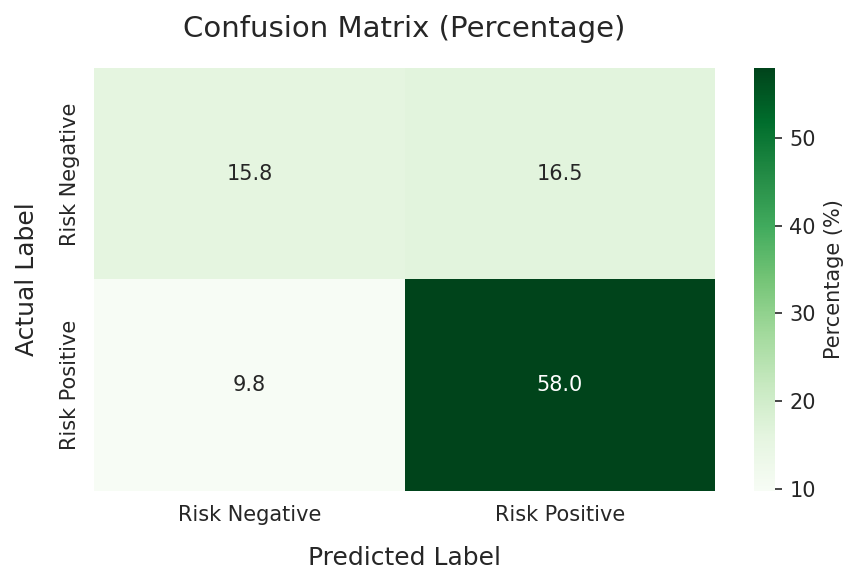

(0.7377892030848329,
 array([[123, 128],
        [ 76, 451]]))

In [68]:
model_Evaluate(best_lr, X_test_transformed)

Too much False Positives

In [69]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd
import time

# ── Shapes Check ──────────────────────────────────────────────────────────
print("Target shapes:")
print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"y_test shape:              {y_test.shape}")

# ── Model Setup (no GridSearch — best known config) ───────────────────────
svc = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42
)

# ── Fit on Train (with runtime) ───────────────────────────────────────────
print("\nTraining SVC...")
start_time = time.time()
svc.fit(X_train_transformed, y_train)
end_time     = time.time()
svc_runtime  = round(end_time - start_time, 4)

# ── Model Info ────────────────────────────────────────────────────────────
print("SVC Parameters:")
print(f"C      : {svc.C}")
print(f"kernel : {svc.kernel}")
print(f"gamma  : {svc.gamma}")
print("Runtime: {:.4f} seconds".format(svc_runtime))

# ── Evaluate on Train and Test ────────────────────────────────────────────
print("\nSVC Evaluation:")
print("Train Accuracy: {:.3f}".format(svc.score(X_train_transformed, y_train)))
print("Test Accuracy:  {:.3f}".format(svc.score(X_test_transformed, y_test)))

# ── Overfitting Check ─────────────────────────────────────────────────────
train_acc_raw = svc.score(X_train_transformed, y_train)
test_acc_raw  = svc.score(X_test_transformed, y_test)
gap           = train_acc_raw - test_acc_raw

if gap > 0.08:
    print(f"Warning: {gap:.3f} accuracy gap suggests overfitting")
else:
    print(f"Good generalization: only {gap:.3f} accuracy gap")

# ── Predict on Train and Test ─────────────────────────────────────────────
y_pred_train = svc.predict(X_train_transformed)
y_pred_test  = svc.predict(X_test_transformed)

# ── Train Metrics ─────────────────────────────────────────────────────────
svc_train_acc  = round(accuracy_score(y_train, y_pred_train), 4)
svc_train_prec = round(precision_score(y_train, y_pred_train, average='weighted'), 4)
svc_train_rec  = round(recall_score(y_train, y_pred_train, average='weighted'), 4)
svc_train_f1   = round(f1_score(y_train, y_pred_train, average='weighted'), 4)

# ── Test Metrics ──────────────────────────────────────────────────────────
svc_acc  = round(accuracy_score(y_test, y_pred_test), 4)
svc_prec = round(precision_score(y_test, y_pred_test, average='weighted'), 4)
svc_rec  = round(recall_score(y_test, y_pred_test, average='weighted'), 4)
svc_f1   = round(f1_score(y_test, y_pred_test, average='weighted'), 4)

# ── Train/Test Performance DataFrame ─────────────────────────────────────
svc_performance = pd.DataFrame({
    'Split':     ['Train', 'Test'],
    'Accuracy':  [svc_train_acc, svc_acc],
    'Precision': [svc_train_prec, svc_prec],
    'Recall':    [svc_train_rec,  svc_rec],
    'F1 Score':  [svc_train_f1,   svc_f1],
})
print("\nSVC — Train vs Test Performance:")
print(svc_performance.to_string(index=False))

# ── Classification Report ─────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Risk Negative', 'Risk Positive']
))

# ── Probability Distribution ──────────────────────────────────────────────
y_probs          = svc.predict_proba(X_test_transformed)
positive_indices = np.where(y_pred_test == 1)[0]
positive_probs   = y_probs[positive_indices, 1]

print(f"\nProbability Distribution for {len(positive_indices)} Risk Positive predictions:")
print(f"  95-100%: {np.sum(positive_probs >= 0.95)}")
print(f"  90-95%:  {np.sum((positive_probs >= 0.90) & (positive_probs < 0.95))}")
print(f"  85-90%:  {np.sum((positive_probs >= 0.85) & (positive_probs < 0.90))}")
print(f"  80-85%:  {np.sum((positive_probs >= 0.80) & (positive_probs < 0.85))}")
print(f"  70-80%:  {np.sum((positive_probs >= 0.70) & (positive_probs < 0.80))}")
print(f"  60-70%:  {np.sum((positive_probs >= 0.60) & (positive_probs < 0.70))}")
print(f"  50-60%:  {np.sum((positive_probs >= 0.50) & (positive_probs < 0.60))}")
print(f"  40-50%:  {np.sum((positive_probs >= 0.40) & (positive_probs < 0.50))}")

# ── Record in Evaluation DataFrame ────────────────────────────────────────
r = evaluation.shape[0]
evaluation.loc[r] = [
    'SVC',
    'SMOTE + RBF Kernel',
    svc_acc,
    svc_prec,
    svc_rec,
    svc_f1,
    f"{svc_runtime}s"
]

evaluation

Target shapes:
X_train_transformed shape: (3110, 39)
y_test shape:              (778,)

Training SVC...
SVC Parameters:
C      : 10
kernel : rbf
gamma  : scale
Runtime: 3.6875 seconds

SVC Evaluation:
Train Accuracy: 0.981
Test Accuracy:  0.731

SVC — Train vs Test Performance:
Split  Accuracy  Precision  Recall  F1 Score
Train    0.9814     0.9814  0.9814    0.9814
 Test    0.7314     0.7289  0.7314    0.7300

Classification Report:
               precision    recall  f1-score   support

Risk Negative       0.59      0.57      0.58       251
Risk Positive       0.80      0.81      0.80       527

     accuracy                           0.73       778
    macro avg       0.69      0.69      0.69       778
 weighted avg       0.73      0.73      0.73       778


Probability Distribution for 536 Risk Positive predictions:
  95-100%: 6
  90-95%:  112
  85-90%:  113
  80-85%:  92
  70-80%:  125
  60-70%:  82
  50-60%:  6
  40-50%:  0


,Model,Details,Accuracy,Precision,Recall,F1 Score,Runtime
0,Logistic Regression,SMOTE + GridSearchCV,0.7378,0.7270,0.7378,0.7288,4.8197s
1,SVC,SMOTE + RBF Kernel,0.7314,0.7289,0.7314,0.7300,3.6875s


              precision    recall  f1-score   support

           0       0.59      0.57      0.58       251
           1       0.80      0.81      0.80       527

    accuracy                           0.73       778
   macro avg       0.69      0.69      0.69       778
weighted avg       0.73      0.73      0.73       778



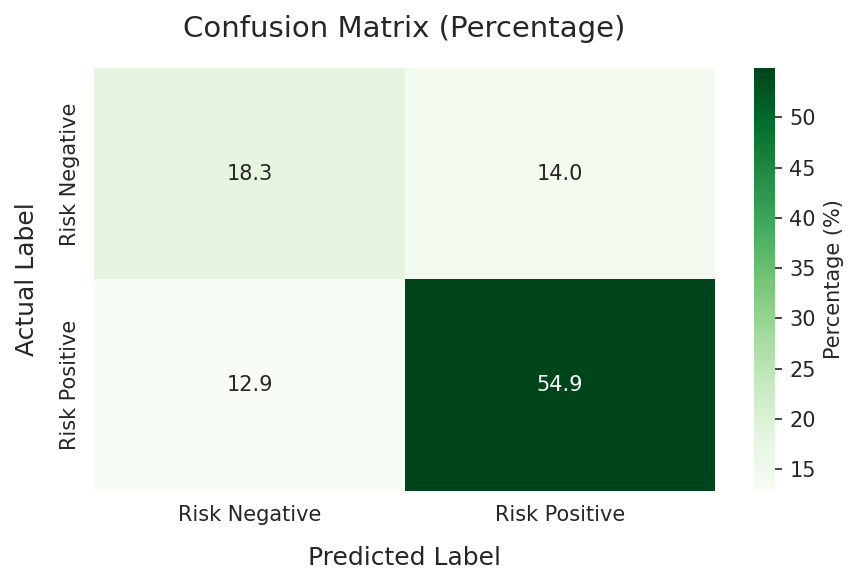

(0.7313624678663239,
 array([[142, 109],
        [100, 427]]))

In [70]:
model_Evaluate(svc, X_test_transformed)

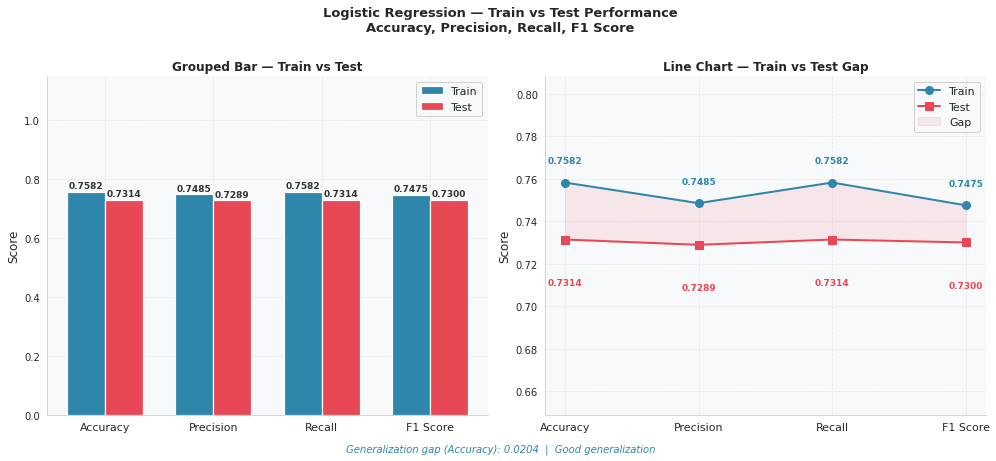

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data from lr_performance ──────────────────────────────────────────────
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [train_acc, train_prec, train_rec, train_f1]
test_scores  = [svc_acc,  svc_prec,  svc_rec,  svc_f1]

COLOR_TRAIN = '#2E86AB'
COLOR_TEST  = '#E84855'
COLOR_BG    = '#F8F9FA'
COLOR_GRID  = '#DEE2E6'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.facecolor':    COLOR_BG,
    'figure.facecolor':  'white',
    'axes.grid':         True,
    'grid.color':        COLOR_GRID,
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
})

x     = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ══════════════════════════════════════════════════════════════════════════
# LEFT — Grouped Bar Chart
# ══════════════════════════════════════════════════════════════════════════
ax1 = axes[0]

bars_train = ax1.bar(
    x - width/2, train_scores,
    width, color=COLOR_TRAIN, edgecolor='white',
    linewidth=1.2, label='Train', zorder=3
)
bars_test = ax1.bar(
    x + width/2, test_scores,
    width, color=COLOR_TEST, edgecolor='white',
    linewidth=1.2, label='Test', zorder=3
)

# Value labels on bars
for bar in bars_train:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )
for bar in bars_test:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=11, framealpha=0.9)
ax1.set_title('Grouped Bar — Train vs Test', fontsize=12, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════
# RIGHT — Line Chart (shows gap clearly)
# ══════════════════════════════════════════════════════════════════════════
ax2 = axes[1]

ax2.plot(
    metrics, train_scores,
    color=COLOR_TRAIN, marker='o', linewidth=2,
    markersize=8, label='Train', zorder=3
)
ax2.plot(
    metrics, test_scores,
    color=COLOR_TEST, marker='s', linewidth=2,
    markersize=8, label='Test', zorder=3
)

# Fill gap between train and test
ax2.fill_between(
    metrics, train_scores, test_scores,
    alpha=0.10, color='#E84855', label='Gap'
)

# Value labels on points
for i, (tr, te) in enumerate(zip(train_scores, test_scores)):
    ax2.text(i, tr + 0.008, f'{tr:.4f}',
             ha='center', va='bottom',
             fontsize=9, color=COLOR_TRAIN, fontweight='bold')
    ax2.text(i, te - 0.018, f'{te:.4f}',
             ha='center', va='top',
             fontsize=9, color=COLOR_TEST, fontweight='bold')

ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(
    min(train_scores + test_scores) - 0.08,
    max(train_scores + test_scores) + 0.05
)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.set_title('Line Chart — Train vs Test Gap', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', labelsize=11)

# ── Shared title ──────────────────────────────────────────────────────────
fig.suptitle(
    'Logistic Regression — Train vs Test Performance\n'
    'Accuracy, Precision, Recall, F1 Score',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Gap summary caption ───────────────────────────────────────────────────
gap = round(train_acc - test_acc, 4)
fig.text(
    0.5, -0.02,
    f'Generalization gap (Accuracy): {gap:.4f}  |  '
    f'{"Warning: possible overfitting" if gap > 0.15 else "Good generalization"}',
    ha='center', fontsize=10, color='#E84855' if gap > 0.15 else '#2E86AB',
    style='italic'
)

plt.tight_layout()
plt.savefig('metrics_lr_train_test.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()